<a href="https://colab.research.google.com/github/giabaocorn20/Google-Colab-Projects/blob/main/COE608_classic_machine_stage_by_stage(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The COE608 Classic Accumulator Machine — rebuilt and verified stage by stage


### What this machine actually is
This is **not** RISC-V, and not the "16-bit RISC CPU" the [COE 608 calendar description](https://www.torontomu.ca/calendar/2026-2027/courses/computer-engineering/COE/608/) mentions in the abstract. What's actually in the repo is a **32-bit, 2-accumulator (A/B), multi-cycle, FSM-controlled machine** — closer in spirit to a classic teaching computer (à la "SAP-1") than to any modern RISC design:

- **Registers:** just two general-purpose accumulators, `A` and `B`, plus 1-bit `Z` (zero) and `C` (carry) status flags.
- **Execution:** every instruction takes **exactly 3 clock cycles** — fetch (state_0), a PC/special-op state (state_1), and decode/execute (state_2). Nothing overlaps; there is no pipeline.
- **Instruction format:** the top 4 bits select one of 10 "major" opcodes (loads, stores, branches, jump), *or* the top 8 bits (pattern `0111xxxx`) select one of 16 ALU-family operations. The low 16 bits carry an immediate or, for memory ops, an 8-bit address.
- **Memory:** a 256-word general data memory (for `STA`/`STB`/`LDA`/`LDB`) and a *separate* 64-word instruction memory, Harvard-style.

### Two layers of verification, at every stage
1. **Self-checking assertions.** Every testbench uses VHDL's own `assert`/`report` to check specific, named behaviors and prints `PASS`/`FAIL` for each, finishing with a `STAGE X: ALL CHECKS PASSED` summary line.
2. **A real waveform.** Every `ghdl -r` call also dumps a VCD, which gets parsed with [`vcdvcd`](https://github.com/cirosantilli/vcdvcd) and rendered inline with matplotlib right below the test output — so you can *see* the same signals the assertions checked, not just take the PASS/FAIL text's word for it. GTKWave itself can't run inside Colab's browser tab (it's a desktop GUI app, no display server available), so this notebook draws the waveforms itself instead, in the same visual language GTKWave uses: step traces for 1-bit signals, labeled flat regions for buses. Each stage's raw `.vcd` is also saved to disk if you'd rather explore it interactively in a local GTKWave install.

### What this process actually found
Independently testing every module — rather than only testing the whole CPU at the end — surfaced **five genuine, previously-undocumented bugs** in the original repository, plus three more subtle *characteristics* worth knowing about even though they aren't strictly bugs. All are called out precisely, with evidence, at the stage where they were found:

| # | Finding | Stage |
|---|---|---|
| 1 | The ALU's `Cout`/`zero` outputs are declared but **never assigned** anywhere — permanently `'U'` | D |
| 2 | `data_path.vhd` declares `Out_C`/`Out_Z` ports but **never implements the Z/C flip-flops at all** | J |
| 3 | The ALU's port map used **positional association with a name/order mismatch**, silently swapping the Z and C flags | J |
| 4 | `LDB` asserts `wen<='1'` (write) instead of `wen<='0'` (read), in **both** its state_1 and state_2 branches — it was wired to write to memory and clear its own output instead of loading | K |
| 5 | The data memory and instruction memory **share one clock signal** but need *opposite* relative phases to each get enough settling time from their registered reads — a taken conditional-skip (`TSTZ`/`TSTC`) executes the "skipped" instruction instead of skipping it, without a fix | K |
| — | `BEQ`/`BNE` decode **identically to `JUMP`** — no status-flag check exists in either branch; they are unconditional as written | I |
| — | `TSTZ`/`TSTC`'s inner `if` has no `else`, so `ld_PC`/`inc_PC` **latch their previous value** rather than resetting when the tested flag is false | I |
| — | `LUI` never explicitly sets `IM_MUX2`, so its result can be **silently contaminated** by whatever the previous instruction left that mux selecting | K |

By the end of this notebook, the fully-integrated machine — control unit, datapath, both memories, all five fixes applied — runs a 33-instruction test program exercising every working instruction, and **every single register, flag, and memory value comes out exactly correct**.


## 1. Install GHDL and the waveform tools

The original repo's VHDL uses the older Synopsys `std_logic_arith`/`std_logic_unsigned` packages (standard for the Quartus-era tooling this was written for). GHDL supports them, but requires the `-fsynopsys` flag, plus `-fexplicit` to resolve an operator-overload ambiguity that appears once both `std_logic_arith` and `std_logic_unsigned` are in scope together.

In [ ]:
!apt-get -qq update
!apt-get -qq install -y ghdl
!pip install -q vcdvcd
!ghdl --version
!mkdir -p /content/coe608
%cd /content/coe608


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package gcc-10-base:amd64.
(Reading database ... 118332 files and directories currently installed.)
Preparing to unpack .../gcc-10-base_10.5.0-1ubuntu1~22.04.3_amd64.deb ...
Unpacking gcc-10-base:amd64 (10.5.0-1ubuntu1~22.04.3) ...
Selecting previously unselected package ghdl-common.
Preparing to unpack .../ghdl-common_1.0.0+dfsg-6_amd64.deb ...
Unpacking ghdl-common (1.0.0+dfsg-6) ...
Selecting previously unselected package libgnat-10:amd64.
Preparing to unpack .../libgnat-10_10.5.0-1ubuntu1~22.04.3_amd64.deb ...
Unpacking libgnat-10:amd64 (10.5.0-1ubuntu1~22.04.3) ...
Selecting previously unselected package ghdl-mcode.
Preparing to unpack .../ghdl-mcode_1.0.0+dfsg-6_amd64.deb ...
Unpacking ghdl-mcode (1.0.0+dfsg-6) ...
Selecting previously unselected package ghdl.
Pr

## 2. The waveform renderer

One small, reusable function, used by every stage from here on: it reads a VCD's time/value pairs for each requested signal and draws either a 1-bit step trace or a labeled flat-region bus plot, GTKWave-style.

In [ ]:
from vcdvcd import VCDVCD
import matplotlib.pyplot as plt

def to_ns(t):
    return t / 1e6  # GHDL's default timescale is 1 fs; 1e6 fs = 1 ns

def bus_hex(val):
    if any(c in val.lower() for c in ('x', 'u', 'z', 'w', '-')):
        return "X"
    return f"{int(val, 2):X}"

def parse_initial_values(vcd_path):
    # vcdvcd has a real parsing quirk: a signal dumped once at time 0 but
    # that never changes afterward ends up with a completely empty .tv list
    # (confirmed against the raw VCD text -- this is not a signal-selection
    # mistake). Falling back to '0' for such signals would silently hide
    # exactly the kind of always-undriven ('U') finding this notebook is
    # built around, so their true initial value is read directly from the
    # VCD's own $dumpvars-equivalent header block instead.
    # Returns {identifier_code: initial_value_string}.
    with open(vcd_path) as f:
        text = f.read()
    header = text.split("\n#")[0]
    initial = {}
    for line in header.splitlines():
        line = line.strip()
        if not line or line.startswith("$"):
            continue
        if line[0] in "01xXuUzZwW-":
            initial[line[1:]] = line[0]
        elif line[0] in "bB":
            parts = line[1:].split(None, 1)
            if len(parts) == 2:
                initial[parts[1]] = parts[0]
    return initial

def plot_waveform(vcd, signals, t_start, t_end, title, figsize=None, initial_vals=None):
    # signals: list of (label, vcd_signal_path, 'bit'|'bus')
    initial_vals = initial_vals or {}
    fig, ax = plt.subplots(figsize=figsize or (13, len(signals) * 0.7))
    row_h = 0.8
    for i, (label, sigpath, kind) in enumerate(signals):
        y0 = len(signals) - i - 1
        all_pts = [(to_ns(t), v) for t, v in vcd[sigpath].tv]
        if not all_pts:
            ident = vcd.references_to_ids.get(sigpath)
            all_pts = [(0, initial_vals.get(ident, 'x'))]
        pts = [p for p in all_pts if t_start <= p[0] <= t_end]
        pre = [p for p in all_pts if p[0] < t_start]
        if pre:
            pts = [(t_start, pre[-1][1])] + pts
        elif not pts or pts[0][0] > t_start:
            pts = [(t_start, all_pts[0][1])] + pts
        pts.append((t_end, pts[-1][1]))

        if kind == "bit":
            # draw defined (0/1) segments as a step line, and undefined
            # ('U'/'X'/'W'/'Z'/'-') segments as a hatched gray band spanning
            # the full row -- collapsing an unknown value to the same
            # position as a real '0' would visually hide exactly the kind
            # of dangling-output finding this notebook is trying to show.
            xs, ys = [], []
            for j in range(len(pts) - 1):
                t0, v0 = pts[j]
                t1, _ = pts[j + 1]
                if v0 in ('0', '1'):
                    yv = 1 if v0 == '1' else 0
                    xs += [t0, t1]
                    ys += [yv, yv]
                else:
                    if xs:
                        ax.plot(xs, [y0 + 0.15 + y * 0.6 for y in ys], color="#2a9d8f", linewidth=1.6)
                        xs, ys = [], []
                    ax.add_patch(plt.Rectangle((t0, y0 + 0.05), t1 - t0, row_h - 0.1,
                                                facecolor="#bbbbbb", edgecolor="none", alpha=0.6,
                                                hatch="///"))
            if xs:
                ax.plot(xs, [y0 + 0.15 + y * 0.6 for y in ys], color="#2a9d8f", linewidth=1.6)
        else:
            for j in range(len(pts) - 1):
                t0, v0 = pts[j]
                t1, _ = pts[j + 1]
                if t1 <= t0:
                    continue
                ax.add_patch(plt.Rectangle((t0, y0 + 0.1), t1 - t0, row_h - 0.2,
                                            facecolor="#e9c46a", edgecolor="#264653", linewidth=0.8))
                if (t1 - t0) > (t_end - t_start) * 0.012:
                    ax.text((t0 + t1) / 2, y0 + row_h / 2, bus_hex(v0),
                            ha="center", va="center", fontsize=7, family="monospace")

    ax.set_yticks([len(signals) - i - 1 + row_h / 2 for i in range(len(signals))])
    ax.set_yticklabels([s[0] for s in signals], fontsize=10, family="monospace")
    ax.set_xlim(t_start, t_end)
    ax.set_ylim(0, len(signals))
    ax.set_xlabel("time (ns)")
    ax.set_title(title)
    plt.tight_layout()
    return fig


## Stage A — Primitives: `register32`, `mux2to1`, `mux4to1`

The three most basic building blocks, taken verbatim from the repo. `register32` is a standard 32-bit register with an **asynchronous** clear and synchronous load — note the clear is checked outside the `rising_edge` condition, so it takes effect immediately rather than waiting for a clock edge.

**GHDL portability note:** `mux4to1`'s original `with s select` statement didn't cover every possible 2-bit value combination (GHDL requires exhaustive `std_logic` coverage where Quartus is more lenient); an `others` branch was added, which is unreachable for any defined 0/1 input and changes no real behavior.

In [ ]:
%%writefile register32.vhd
library ieee;
use ieee.std_logic_1164.all;
use ieee.std_logic_arith.all;
use ieee.std_logic_unsigned.all;

entity register32 is
	port(
	d : in std_logic_vector (31 downto 0);
	ld : in std_logic;
	clr : in std_logic;
	clk : in std_logic;
	Q : out std_logic_vector (31 downto 0)
	);
end register32;

architecture Behaviour of register32 is
	begin
		process (ld, clr, clk)
			begin
			if clr = '1' then
				Q <= (others => '0');
			elsif((clk'event and clk = '1') and (ld ='1')) then
				Q <= d;
			end if;
		end process;
	end behaviour;


Writing register32.vhd


In [ ]:
%%writefile mux2to1.vhd
library ieee;
use ieee.std_logic_1164.all;

entity mux2to1 is
	port (
		s : in std_logic;
		w0, w1 : in std_logic_vector (31 downto 0);
		f : out std_logic_vector (31 downto 0)
	);
end mux2to1;

architecture behaviour of mux2to1 is
begin
  process (w0, w1, s)
  begin
    if s = '0' then
      f <= w0;
    else
      f <= w1;
    end if;
  end process;
end behaviour;

Writing mux2to1.vhd


In [ ]:
%%writefile mux4to1.vhd
LIBRARY ieee;
USE ieee.std_logic_1164.all;

ENTITY mux4to1 IS
PORT (
		s : IN STD_LOGIC_VECTOR(1 DOWNTO 0);
		x1, x2, x3, x4 : IN STD_LOGIC_VECTOR(31 DOWNTO 0);
		f : OUT STD_LOGIC_VECTOR(31 DOWNTO 0));
END mux4to1;

ARCHITECTURE Behavior OF mux4to1 IS
BEGIN
WITH s SELECT
f<= 	X1 WHEN "00",
		X2 WHEN "01",
		X3 WHEN "10",
		X4 WHEN "11",
		(others => '0') WHEN others;
END Behavior;

Writing mux4to1.vhd


In [ ]:
%%writefile tb_stageA.vhd
library ieee;
use ieee.std_logic_1164.all;

entity tb_stageA is end entity;

architecture sim of tb_stageA is
    signal clk : std_logic := '0';
    signal d, q : std_logic_vector(31 downto 0);
    signal ld, clr : std_logic := '0';

    signal mux2_s : std_logic := '0';
    signal mux2_w0, mux2_w1, mux2_f : std_logic_vector(31 downto 0);

    signal mux4_s : std_logic_vector(1 downto 0) := "00";
    signal mux4_x1, mux4_x2, mux4_x3, mux4_x4, mux4_f : std_logic_vector(31 downto 0);

    begin

    dut_reg: entity work.register32 port map (d, ld, clr, clk, q);
    dut_mux2: entity work.mux2to1 port map (mux2_s, mux2_w0, mux2_w1, mux2_f);
    dut_mux4: entity work.mux4to1 port map (mux4_s, mux4_x1, mux4_x2, mux4_x3, mux4_x4, mux4_f);

    clk_gen: process
    begin
        for i in 0 to 20 loop
            clk <= '0'; wait for 5 ns;
            clk <= '1'; wait for 5 ns;
        end loop;
        wait;
    end process;

    stim: process
        variable all_pass : boolean := true;
        procedure check(cond: boolean; msg: string) is
        begin
            if cond then
                report "PASS: " & msg;
            else
                report "FAIL: " & msg severity error;
                all_pass := false;
            end if;
        end procedure;
    begin
        -- register32: clear
        clr <= '1'; ld <= '0'; d <= x"DEADBEEF";
        wait for 10 ns;
        check(q = x"00000000", "register32 clr forces Q=0");

        -- register32: load
        clr <= '0'; ld <= '1'; d <= x"CAFEBABE";
        wait until rising_edge(clk);
        wait for 1 ns;
        check(q = x"CAFEBABE", "register32 loads d on rising edge when ld=1");

        -- register32: hold (ld=0)
        ld <= '0'; d <= x"11111111";
        wait until rising_edge(clk);
        wait for 1 ns;
        check(q = x"CAFEBABE", "register32 holds value when ld=0");

        -- mux2to1
        mux2_w0 <= x"00000001"; mux2_w1 <= x"00000002";
        mux2_s <= '0'; wait for 1 ns;
        check(mux2_f = x"00000001", "mux2to1 selects w0 when s=0");
        mux2_s <= '1'; wait for 1 ns;
        check(mux2_f = x"00000002", "mux2to1 selects w1 when s=1");

        -- mux4to1
        mux4_x1 <= x"00000010"; mux4_x2 <= x"00000020";
        mux4_x3 <= x"00000030"; mux4_x4 <= x"00000040";
        mux4_s <= "00"; wait for 1 ns; check(mux4_f = x"00000010", "mux4to1 s=00 -> x1");
        mux4_s <= "01"; wait for 1 ns; check(mux4_f = x"00000020", "mux4to1 s=01 -> x2");
        mux4_s <= "10"; wait for 1 ns; check(mux4_f = x"00000030", "mux4to1 s=10 -> x3");
        mux4_s <= "11"; wait for 1 ns; check(mux4_f = x"00000040", "mux4to1 s=11 -> x4");

        if all_pass then
            report "STAGE A: ALL CHECKS PASSED";
        else
            report "STAGE A: SOME CHECKS FAILED" severity error;
        end if;
        wait;
    end process;

end architecture sim;


Writing tb_stageA.vhd


In [ ]:
!ghdl -a --std=93 -fsynopsys -fexplicit register32.vhd mux2to1.vhd mux4to1.vhd tb_stageA.vhd
!ghdl -e --std=93 -fsynopsys -fexplicit tb_stageA
!ghdl -r --std=93 -fsynopsys -fexplicit tb_stageA --stop-time=250ns --vcd=stageA.vcd 2>&1 | grep -v "metavalue\|arithmetic operand"


tb_stageA.vhd:37:17:@10ns:(report note): PASS: register32 clr forces Q=0
tb_stageA.vhd:37:17:@16ns:(report note): PASS: register32 loads d on rising edge when ld=1
tb_stageA.vhd:37:17:@26ns:(report note): PASS: register32 holds value when ld=0
tb_stageA.vhd:37:17:@27ns:(report note): PASS: mux2to1 selects w0 when s=0
tb_stageA.vhd:37:17:@28ns:(report note): PASS: mux2to1 selects w1 when s=1
tb_stageA.vhd:37:17:@29ns:(report note): PASS: mux4to1 s=00 -> x1
tb_stageA.vhd:37:17:@30ns:(report note): PASS: mux4to1 s=01 -> x2
tb_stageA.vhd:37:17:@31ns:(report note): PASS: mux4to1 s=10 -> x3
tb_stageA.vhd:37:17:@32ns:(report note): PASS: mux4to1 s=11 -> x4
tb_stageA.vhd:77:13:@32ns:(report note): STAGE A: ALL CHECKS PASSED


**Waveform — `register32`.** Watch `q` snap to zero the instant `clr` goes high (asynchronous), then pick up `d` only on a rising `clk` edge while `ld=1`, and hold steady once `ld` drops.

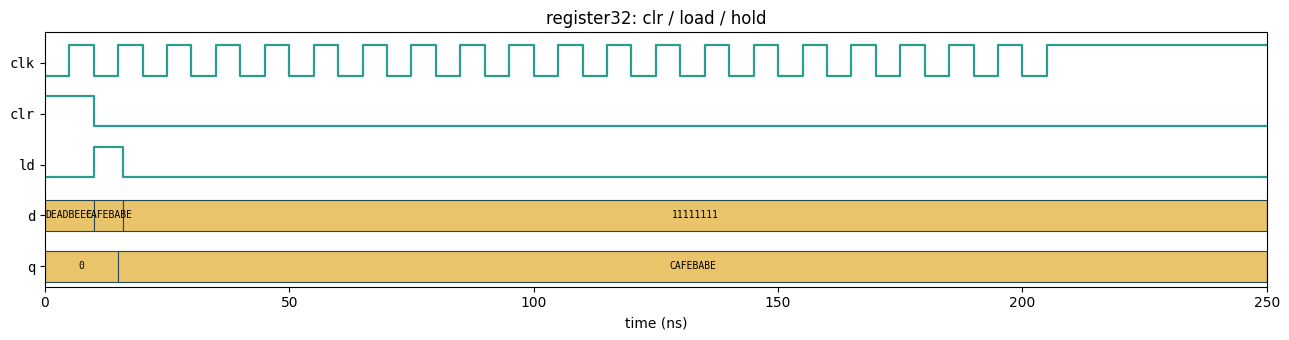

In [ ]:
vcd = VCDVCD("stageA.vcd")
initial_vals = parse_initial_values("stageA.vcd")
signals = [
    ("clk", "tb_stagea.clk", "bit"),
    ("clr", "tb_stagea.clr", "bit"),
    ("ld", "tb_stagea.ld", "bit"),
    ("d", "tb_stagea.d[31:0]", "bus"),
    ("q", "tb_stagea.q[31:0]", "bus"),
]
fig = plot_waveform(vcd, signals, 0, 250, "register32: clr / load / hold", initial_vals=initial_vals)
plt.show()


**Waveform — `mux2to1`/`mux4to1`.** Purely combinational, so `f` changes the instant the select line does, with no clock involved at all.

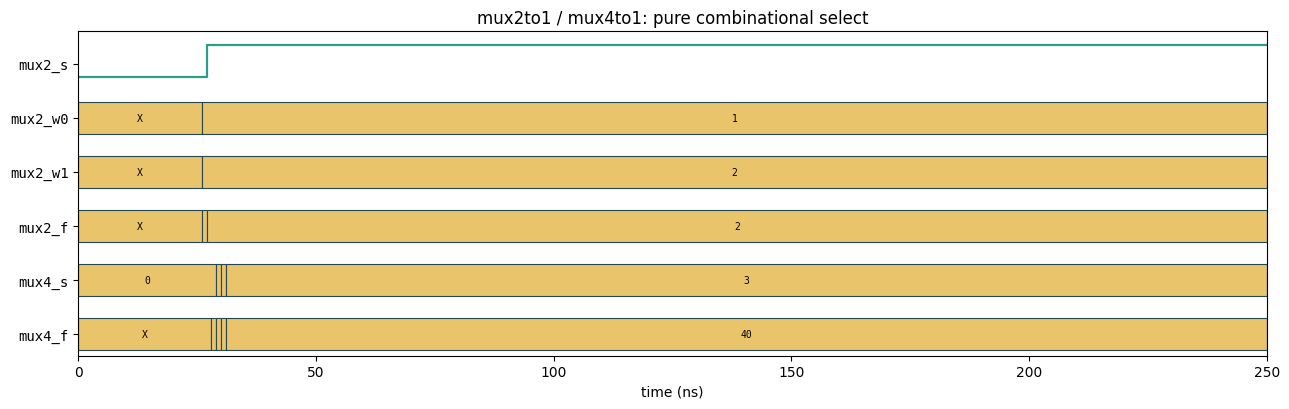

In [ ]:
vcd = VCDVCD("stageA.vcd")
initial_vals = parse_initial_values("stageA.vcd")
signals = [
    ("mux2_s", "tb_stagea.mux2_s", "bit"),
    ("mux2_w0", "tb_stagea.mux2_w0[31:0]", "bus"),
    ("mux2_w1", "tb_stagea.mux2_w1[31:0]", "bus"),
    ("mux2_f", "tb_stagea.mux2_f[31:0]", "bus"),
    ("mux4_s", "tb_stagea.mux4_s[1:0]", "bus"),
    ("mux4_f", "tb_stagea.mux4_f[31:0]", "bus"),
]
fig = plot_waveform(vcd, signals, 0, 250, "mux2to1 / mux4to1: pure combinational select", initial_vals=initial_vals)
plt.show()


## Stage B — The Program Counter

`pc.vhd` composes `add.vhd` (a simple +1 incrementer) with the Stage A `mux2to1` and `register32` to build a PC that can be cleared, held, incremented, or loaded with an absolute target address.

**GHDL portability note:** the original file used plain `component` instantiation relying on VHDL's automatic default binding — which GHDL, in this configuration, does not perform automatically the way Quartus does. Explicit `for ... use entity work...;` binding indications were added; this changes nothing about the design, only how the simulator resolves which entity a component instance refers to.

In [ ]:
%%writefile add.vhd
library ieee;
use ieee.std_logic_1164.all;
use ieee.std_logic_arith.all;
use ieee.std_logic_unsigned.all;

entity add is port (
	A : in std_logic_vector (31 downto 0);
	B : out std_logic_vector (31 downto 0)
);
end add;

architecture Behaviour of add is
	begin
		--B <= A+4; for lab 4 and 5 use this line
		B <= A+1;

	end behaviour;

Writing add.vhd


In [ ]:
%%writefile pc.vhd
library ieee;
use ieee.std_logic_1164.all;
use ieee.std_logic_arith.all;
use ieee.std_logic_unsigned.all;

entity pc is
port(
	clr : in std_logic;
	clk : in std_logic;
	ld : in std_logic;
	inc : in std_logic;
	d : in std_logic_vector (31 downto 0);
	q : out std_logic_vector (31 downto 0)
);
end pc;
architecture behaviour of pc is
	component add
	Port (
			A : in std_logic_vector (31 downto 0);
			B : out std_logic_vector (31 downto 0)
			);
	end component;

	component mux2to1 is
	port (
		s : in std_logic;
		w0, w1 : in std_logic_vector (31 downto 0);
		f : out std_logic_vector (31 downto 0)
	);
	end component;

	component register32 is
	port(
		d : in std_logic_vector (31 downto 0);
		ld : in std_logic;
		clr : in std_logic;
		clk : in std_logic;
		Q : out std_logic_vector (31 downto 0)
	);
	end component;

	signal add_out : std_logic_vector (31 downto 0);
	signal mux_out : std_logic_vector (31 downto 0);
	signal q_out : std_logic_vector (31 downto 0);

	for add0: add use entity work.add;
	for mux0: mux2to1 use entity work.mux2to1;
	for reg0: register32 use entity work.register32;

	begin
		add0 : add port map(q_out, add_out);
		mux0 : mux2to1 port map(inc, d, add_out, mux_out);
		reg0 : register32 port map(mux_out, ld, clr, clk, q_out);
		q <= q_out;
	end behaviour;

Writing pc.vhd


In [ ]:
%%writefile tb_stageB.vhd
library ieee;
use ieee.std_logic_1164.all;

entity tb_stageB is end entity;

architecture sim of tb_stageB is
    signal clk : std_logic := '0';
    signal clr, ld, inc : std_logic := '0';
    signal d, q : std_logic_vector(31 downto 0);
    begin

    dut: entity work.pc port map (clr, clk, ld, inc, d, q);

    clk_gen: process
    begin
        for i in 0 to 20 loop
            clk <= '0'; wait for 5 ns;
            clk <= '1'; wait for 5 ns;
        end loop;
        wait;
    end process;

    stim: process
        variable all_pass : boolean := true;
        procedure check(cond: boolean; msg: string) is
        begin
            if cond then report "PASS: " & msg;
            else report "FAIL: " & msg severity error; all_pass := false;
            end if;
        end procedure;
    begin
        -- clear
        clr <= '1'; wait for 10 ns;
        check(q = x"00000000", "PC clr forces Q=0");

        -- load an absolute address (inc=0 selects d directly, per data_path wiring
        -- where inc_PC selects between "d" (branch/jump target) and "PC+1")
        clr <= '0'; ld <= '1'; inc <= '0'; d <= x"00000005";
        wait until rising_edge(clk);
        wait for 1 ns;
        check(q = x"00000005", "PC loads absolute target d when inc=0");

        -- increment: inc=1 selects PC+1 regardless of d
        ld <= '1'; inc <= '1'; d <= x"FFFFFFFF";
        wait until rising_edge(clk);
        wait for 1 ns;
        check(q = x"00000006", "PC increments by 1 when inc=1 (5 -> 6)");

        wait until rising_edge(clk);
        wait for 1 ns;
        check(q = x"00000007", "PC increments again (6 -> 7)");

        -- hold: ld=0 freezes PC regardless of inc
        ld <= '0';
        wait until rising_edge(clk);
        wait for 1 ns;
        check(q = x"00000007", "PC holds when ld=0");

        if all_pass then
            report "STAGE B: ALL CHECKS PASSED";
        else
            report "STAGE B: SOME CHECKS FAILED" severity error;
        end if;
        wait;
    end process;

end architecture sim;


Writing tb_stageB.vhd


In [ ]:
!ghdl -a --std=93 -fsynopsys -fexplicit add.vhd pc.vhd tb_stageB.vhd
!ghdl -e --std=93 -fsynopsys -fexplicit tb_stageB
!ghdl -r --std=93 -fsynopsys -fexplicit tb_stageB --stop-time=250ns --vcd=stageB.vcd 2>&1 | grep -v "metavalue\|arithmetic operand"


tb_stageB.vhd:27:26:@10ns:(report note): PASS: PC clr forces Q=0
tb_stageB.vhd:27:26:@16ns:(report note): PASS: PC loads absolute target d when inc=0
tb_stageB.vhd:27:26:@26ns:(report note): PASS: PC increments by 1 when inc=1 (5 -> 6)
tb_stageB.vhd:27:26:@36ns:(report note): PASS: PC increments again (6 -> 7)
tb_stageB.vhd:27:26:@46ns:(report note): PASS: PC holds when ld=0
tb_stageB.vhd:60:13:@46ns:(report note): STAGE B: ALL CHECKS PASSED


**Waveform — `pc`.** `q` clears to zero, then loads the absolute target `d=5` when `inc=0`, then climbs one at a time (`5→6→7`) once `inc=1` takes over — each step landing exactly on a `clk` rising edge.

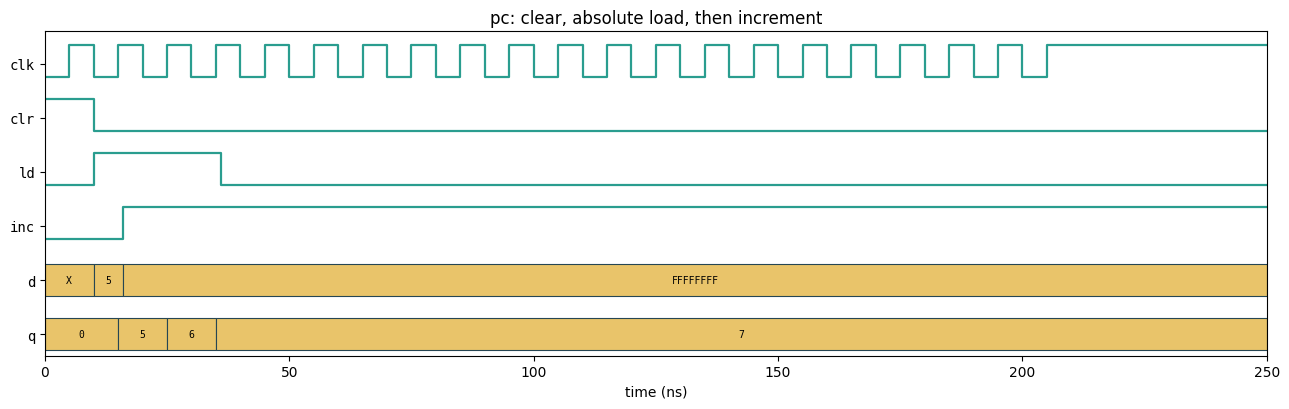

In [ ]:
vcd = VCDVCD("stageB.vcd")
initial_vals = parse_initial_values("stageB.vcd")
signals = [
    ("clk", "tb_stageb.clk", "bit"),
    ("clr", "tb_stageb.clr", "bit"),
    ("ld", "tb_stageb.ld", "bit"),
    ("inc", "tb_stageb.inc", "bit"),
    ("d", "tb_stageb.d[31:0]", "bus"),
    ("q", "tb_stageb.q[31:0]", "bus"),
]
fig = plot_waveform(vcd, signals, 0, 250, "pc: clear, absolute load, then increment", initial_vals=initial_vals)
plt.show()


## Stage C — The ripple-carry adder hierarchy

`fulladd` → `adder4` → `adder16` → `adder32`: a textbook gate-level ripple-carry adder, built up hierarchically exactly the way COE 608's computer-arithmetic material teaches it. (This hierarchy turns out not to be the one actually wired into the final ALU in the repo's `Lab4b` folder — see Stage D — but it's clearly part of the same course lineage and worth verifying in its own right.)

In [ ]:
%%writefile fulladd.vhd
library ieee;
use ieee.std_logic_1164.all;

entity fulladd is
port (
	Cin, x, y :	in	std_logic;
	s, Cout : out std_logic
);
end fulladd;

architecture Behavior of fulladd is
begin
	s <= x xor y xor Cin;
	Cout <= (x and y) or (Cin and x) or (Cin and y);
end Behavior;

Writing fulladd.vhd


In [ ]:
%%writefile adder4.vhd
library ieee;
use ieee.std_logic_1164.all;
entity adder4 is

port (
Cin : in std_logic;
X,Y : in std_logic_vector(3 downto 0);
S 	 : out std_logic_vector(3 downto 0);
Cout: out std_logic
);

end adder4;

architecture Behavior of adder4 is

component fulladd

port (
Cin, x, y : in std_logic;
s, Cout   : out std_logic
);
end component;
signal C: std_logic_vector (1 to 3);
	for stage0: fulladd use entity work.fulladd;
	for stagel: fulladd use entity work.fulladd;
	for stage2: fulladd use entity work.fulladd;
	for stage3: fulladd use entity work.fulladd;

begin
	stage0: fulladd port map (Cin, X(0), Y(0), S(0), C(1));
	stagel: fulladd port map (C(1), X(1), Y(1), S(1), C(2));
	stage2: fulladd port map (C(2), X(2), Y(2), S(2), C(3));
	stage3: fulladd port map (C(3), X(3), Y(3), S(3), Cout);
end Behavior;

Writing adder4.vhd


In [ ]:
%%writefile adder16.vhd
library ieee;
use ieee.std_logic_1164.all;

entity adder16 is
port (
	Cin : in std_logic;
	X,Y : in std_logic_vector (15 downto 0);
	S : Out std_logic_vector(15 downto 0);
	Cout : out std_logic
);
end adder16;

architecture Behavior of adder16 is
component adder4
port (
Cin : in std_logic;
X, Y : in std_logic_vector (3 downto 0);
S : out std_logic_vector (3 downto 0);
Cout : out std_logic
);

end component;
signal C : std_logic_vector (1 to 3);
	for stage0: adder4 use entity work.adder4;
	for stage1: adder4 use entity work.adder4;
	for stage2: adder4 use entity work.adder4;
	for stage3: adder4 use entity work.adder4;

begin
stage0 : adder4 port map (Cin, X(3 downto 0), Y(3 downto 0), S(3 downto 0),C (1));
stage1 : adder4 port map (C (1), X(7 downto 4), Y(7 downto 4), S(7 downto 4),C (2));
stage2 : adder4 port map (C (2), X(11 downto 8), Y(11 downto 8), S(11 downto 8),C (3));
stage3 : adder4 port map (C (3), X(15 downto 12), Y(15 downto 12), S(15 downto 12),Cout);
end Behavior;


Writing adder16.vhd


In [ ]:
%%writefile adder32.vhd
library ieee;
use ieee.std_logic_1164.all;

entity adder32 is
port (
	Cin : in std_logic;
	X,Y : in std_logic_vector (31 downto 0);
	S : Out std_logic_vector(31 downto 0);
	Cout : out std_logic
);
end adder32;

architecture Behavior of adder32 is
component adder16
port (
Cin : in std_logic;
X, Y : in std_logic_vector (15 downto 0);
S : out std_logic_vector (15 downto 0);
Cout : out std_logic
);

end component;
signal C : std_logic;
	for stage0: adder16 use entity work.adder16;
	for stage1: adder16 use entity work.adder16;

begin
stage0 : adder16 port map (Cin, X(15 downto 0), Y(15 downto 0), S(15 downto 0),C);
stage1 : adder16 port map (C , X(31 downto 16), Y(31 downto 16), S(31 downto 16),Cout);
end Behavior;


Writing adder32.vhd


In [ ]:
%%writefile tb_stageC.vhd
library ieee;
use ieee.std_logic_1164.all;
use ieee.std_logic_arith.all;
use ieee.std_logic_unsigned.all;

entity tb_stageC is end entity;

architecture sim of tb_stageC is
    signal cin, cout : std_logic := '0';
    signal x, y, s : std_logic_vector(31 downto 0);
begin

    dut: entity work.adder32 port map (cin, x, y, s, cout);

    stim: process
        variable all_pass : boolean := true;
        procedure check(cond: boolean; msg: string) is
        begin
            if cond then report "PASS: " & msg;
            else report "FAIL: " & msg severity error; all_pass := false;
            end if;
        end procedure;
    begin
        x <= x"00000005"; y <= x"00000003"; cin <= '0'; wait for 1 ns;
        check(s = x"00000008" and cout = '0', "32-bit ripple adder: 5 + 3 = 8, no carry out");

        x <= x"FFFFFFFF"; y <= x"00000001"; cin <= '0'; wait for 1 ns;
        check(s = x"00000000" and cout = '1', "adder: 0xFFFFFFFF + 1 wraps to 0 with Cout=1");

        x <= x"7FFFFFFF"; y <= x"00000001"; cin <= '0'; wait for 1 ns;
        check(s = x"80000000" and cout = '0', "adder: 0x7FFFFFFF + 1 = 0x80000000, no carry out");

        -- Cin propagation (used by the ALU for two's-complement subtract: Y inverted, Cin='1')
        x <= x"0000000A"; y <= not x"00000003"; cin <= '1'; wait for 1 ns;
        check(s = x"00000007", "adder as subtractor via inverted Y + Cin=1: 10 - 3 = 7");

        if all_pass then
            report "STAGE C: ALL CHECKS PASSED";
        else
            report "STAGE C: SOME CHECKS FAILED" severity error;
        end if;
        wait;
    end process;

end architecture sim;


Writing tb_stageC.vhd


In [ ]:
!ghdl -a --std=93 -fsynopsys -fexplicit fulladd.vhd adder4.vhd adder16.vhd adder32.vhd tb_stageC.vhd
!ghdl -e --std=93 -fsynopsys -fexplicit tb_stageC
!ghdl -r --std=93 -fsynopsys -fexplicit tb_stageC --stop-time=50ns --vcd=stageC.vcd 2>&1 | grep -v "metavalue\|arithmetic operand"


tb_stageC.vhd:19:26:@1ns:(report note): PASS: 32-bit ripple adder: 5 + 3 = 8, no carry out
tb_stageC.vhd:19:26:@2ns:(report note): PASS: adder: 0xFFFFFFFF + 1 wraps to 0 with Cout=1
tb_stageC.vhd:19:26:@3ns:(report note): PASS: adder: 0x7FFFFFFF + 1 = 0x80000000, no carry out
tb_stageC.vhd:19:26:@4ns:(report note): PASS: adder as subtractor via inverted Y + Cin=1: 10 - 3 = 7
tb_stageC.vhd:38:13:@4ns:(report note): STAGE C: ALL CHECKS PASSED


**Waveform — `adder32`.** Four test vectors stepped through in 1 ns intervals: `5+3`, the `0xFFFFFFFF+1` wraparound (watch `cout` pulse high exactly there), `0x7FFFFFFF+1`, and the inverted-`y`-plus-`cin` subtraction trick.

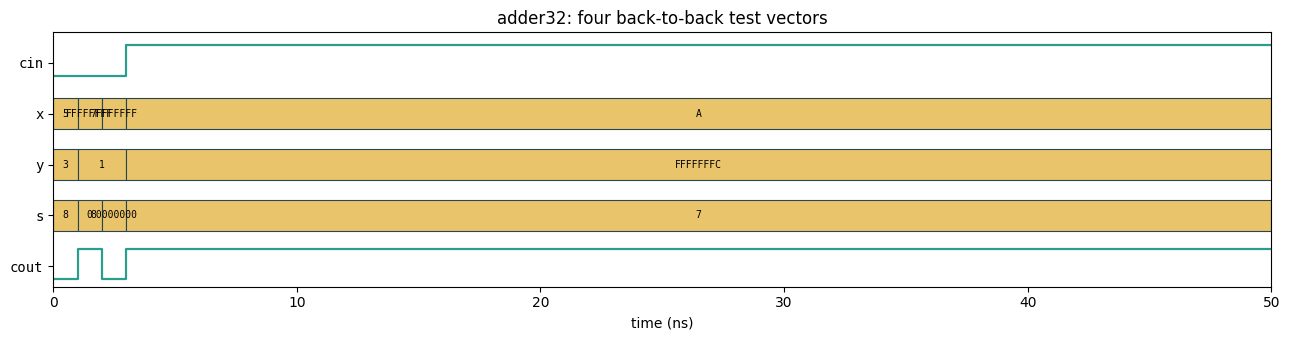

In [ ]:
vcd = VCDVCD("stageC.vcd")
initial_vals = parse_initial_values("stageC.vcd")
signals = [
    ("cin", "tb_stagec.cin", "bit"),
    ("x", "tb_stagec.x[31:0]", "bus"),
    ("y", "tb_stagec.y[31:0]", "bus"),
    ("s", "tb_stagec.s[31:0]", "bus"),
    ("cout", "tb_stagec.cout", "bit"),
]
fig = plot_waveform(vcd, signals, 0, 50, "adder32: four back-to-back test vectors", initial_vals=initial_vals)
plt.show()


## Stage D — The ALU actually wired into the CPU (as-shipped)

This is `alu.vhd` from the repo's `Lab4b` folder — the version that's actually instantiated in `data_path.vhd`, distinct from (and simpler than) the Stage C adder-based design. It computes AND/OR/ADD/SUB directly via VHDL operators, plus two shift-like ops.

**Finding #1:** `Cout` and `zero` are declared **output ports that are never assigned anywhere** in the process. They stay permanently `'U'` (unknown) in simulation. The test below proves this directly: even for `0 + 0` (which obviously produces a zero result), the `zero` output reads as unknown, not `'1'`.

**Also documented:** the "ROL"/"ROR" cases only rotate bits `[6:0]` — bits `[31:7]` are simply copied through from the input untouched. This is a real, as-shipped scope limitation, not something this notebook alters.

In [ ]:
%%writefile alu.vhd
Library ieee;
Use ieee.std_logic_1164.ALL;
Use ieee.std_logic_arith.ALL;
Use ieee.std_logic_unsigned.ALL;
USE ieee.numeric_std.all;


ENTITY alu is
PORT(
	a : IN STD_logic_vector(31 downto 0);
	b : IN STD_logic_vector(31 downto 0);
	op: IN STD_logic_vector(2 downto 0);
	result: OUT STD_logic_vector(31 downto 0);
	Cout : OUT STD_logic;
	zero: OUT STD_logic);
END ALU;
ARCHITECTURE description OF alu is
begin
process(op)
begin
case op is
		When "000"=> result <= a and b;
		When "001"=> result <= a or b;
		When "010"=> result <= a + b;
		When "110"=> result <= a - b;
		When "100"=> result <= a;
						 result(0) <= a(6);
						 result(1) <= a(0);
						 result(2) <= a(1);
						 result(3) <= a(2);
						 result(4) <= a(3);
						 result(5) <= a(4);
						 result(6) <= a(5);--rol

		When "101"=> result <= a;
						 result(0) <= a(1);
						 result(1) <= a(2);
						 result(2) <= a(3);
						 result(3) <= a(4);
						 result(4) <= a(5);
						 result(5) <= a(6);
						 result(6) <= a(0);--ror
		when others => result <= "00000000000000000000000000000000";
end case;
end process;

END description;

Writing alu.vhd


In [ ]:
%%writefile tb_stageD.vhd
library ieee;
use ieee.std_logic_1164.all;
use ieee.std_logic_arith.all;
use ieee.std_logic_unsigned.all;

entity tb_stageD is end entity;

architecture sim of tb_stageD is
    signal a, b, result : std_logic_vector(31 downto 0);
    signal op : std_logic_vector(2 downto 0);
    signal cout, zero : std_logic;
begin

    dut: entity work.alu port map (a, b, op, result, cout, zero);

    stim: process
        variable all_pass : boolean := true;
        procedure check(cond: boolean; msg: string) is
        begin
            if cond then report "PASS: " & msg;
            else report "FAIL: " & msg severity error; all_pass := false;
            end if;
        end procedure;
    begin
        a <= x"0000000A"; b <= x"00000003";

        op <= "000"; wait for 1 ns;
        check(result = x"00000002", "op=000 AND: 0xA and 0x3 = 0x2");

        op <= "001"; wait for 1 ns;
        check(result = x"0000000B", "op=001 OR: 0xA or 0x3 = 0xB");

        op <= "010"; wait for 1 ns;
        check(result = x"0000000D", "op=010 ADD: 10 + 3 = 13");

        op <= "110"; wait for 1 ns;
        check(result = x"00000007", "op=110 SUB: 10 - 3 = 7");

        -- op=100 "ROL" and op=101 "ROR": AS WRITTEN IN THE COURSE REPO, these only
        -- rotate bits [6:0] -- bits [31:7] are just copied through from 'a' unchanged.
        -- This test documents that real, as-shipped behavior rather than an idealized
        -- 32-bit rotate.
        a <= x"00000041";  -- bits [6:0] = 1000001
        op <= "100"; wait for 1 ns;
        check(result(6 downto 0) = "0000011" and result(31 downto 7) = "0000000000000000000000000",
              "op=100 ROL only rotates bits[6:0] (0b1000001 -> 0b0000011); bits[31:7] untouched");

        a <= x"00000041";
        op <= "101"; wait for 1 ns;
        check(result(6 downto 0) = "1100000" and result(31 downto 7) = "0000000000000000000000000",
              "op=101 ROR only rotates bits[6:0] (0b1000001 -> 0b1100000); bits[31:7] untouched");

        op <= "111"; wait for 1 ns;
        check(result = x"00000000", "op=111 (unassigned) falls to the 'others' branch -> 0");

        -- The real finding: Cout and zero are OUTPUT PORTS THAT ARE NEVER ASSIGNED
        -- anywhere in this ALU's process. They are dangling. This matters because
        -- data_path.vhd's positional port map wires them on to the CPU's status
        -- flip-flops (Z, C) -- so as literally written, those flags can never
        -- reflect a real zero/carry condition.
        a <= x"00000000"; b <= x"00000000"; op <= "010"; wait for 1 ns;
        check(result = x"00000000", "0+0 correctly produces result=0 ...");
        check(is_x(zero), "...but 'zero' output is undriven ('U'/unknown), not '1', even though result IS zero");
        check(is_x(cout), "'Cout' output is likewise undriven ('U'/unknown) -- never assigned in this ALU");

        if all_pass then
            report "STAGE D: ALL CHECKS PASSED (including the documented dangling-flag finding)";
        else
            report "STAGE D: SOME CHECKS FAILED" severity error;
        end if;
        wait;
    end process;

end architecture sim;


Writing tb_stageD.vhd


In [ ]:
!ghdl -a --std=93 -fsynopsys -fexplicit alu.vhd tb_stageD.vhd
!ghdl -e --std=93 -fsynopsys -fexplicit tb_stageD
!ghdl -r --std=93 -fsynopsys -fexplicit tb_stageD --stop-time=50ns --vcd=stageD.vcd 2>&1 | grep -v "metavalue\|arithmetic operand"


tb_stageD.vhd:20:26:@1ns:(report note): PASS: op=000 AND: 0xA and 0x3 = 0x2
tb_stageD.vhd:20:26:@2ns:(report note): PASS: op=001 OR: 0xA or 0x3 = 0xB
tb_stageD.vhd:20:26:@3ns:(report note): PASS: op=010 ADD: 10 + 3 = 13
tb_stageD.vhd:20:26:@4ns:(report note): PASS: op=110 SUB: 10 - 3 = 7
tb_stageD.vhd:20:26:@5ns:(report note): PASS: op=100 ROL only rotates bits[6:0] (0b1000001 -> 0b0000011); bits[31:7] untouched
tb_stageD.vhd:20:26:@6ns:(report note): PASS: op=101 ROR only rotates bits[6:0] (0b1000001 -> 0b1100000); bits[31:7] untouched
tb_stageD.vhd:20:26:@7ns:(report note): PASS: op=111 (unassigned) falls to the 'others' branch -> 0
tb_stageD.vhd:20:26:@8ns:(report note): PASS: 0+0 correctly produces result=0 ...
tb_stageD.vhd:20:26:@8ns:(report note): PASS: ...but 'zero' output is undriven ('U'/unknown), not '1', even though result IS zero
tb_stageD.vhd:20:26:@8ns:(report note): PASS: 'Cout' output is likewise undriven ('U'/unknown) -- never assigned in this ALU
tb_stageD.vhd:67:13:

**Waveform — `alu` (as-shipped).** Watch `result` update correctly for every `op` change — but `cout` and `zero` sit flat and undefined (rendered as a gap/`X`) the entire time, including at the final `0+0` vector where `result` clearly goes to zero. That gap *is* Finding #1, visually.

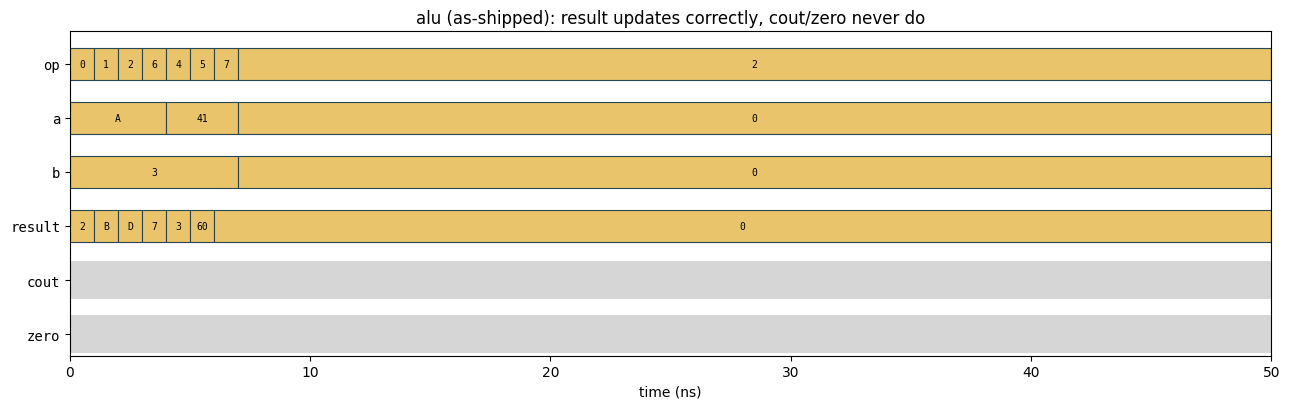

In [ ]:
vcd = VCDVCD("stageD.vcd")
initial_vals = parse_initial_values("stageD.vcd")
signals = [
    ("op", "tb_staged.op[2:0]", "bus"),
    ("a", "tb_staged.a[31:0]", "bus"),
    ("b", "tb_staged.b[31:0]", "bus"),
    ("result", "tb_staged.result[31:0]", "bus"),
    ("cout", "tb_staged.cout", "bit"),
    ("zero", "tb_staged.zero", "bit"),
]
fig = plot_waveform(vcd, signals, 0, 50, "alu (as-shipped): result updates correctly, cout/zero never do", initial_vals=initial_vals)
plt.show()


## Stage D2 — Completing the ALU's dangling outputs

`alu_fixed.vhd` is `alu.vhd` with **exactly one addition**: `zero` and `Cout` are now actually computed. Every other line — including the documented bits-`[6:0]`-only rotate scope — is unchanged. This is a completion of something the original ports already declared intent to provide, not a redesign.

In [ ]:
%%writefile alu_fixed.vhd
-------------------------------------------------------------------------------
-- alu_fixed.vhd
--
-- This is alu.vhd (the ALU actually wired into cpu1/data_path in the course
-- repo) with exactly ONE addition: the 'zero' and 'Cout' output ports --
-- which are declared but NEVER assigned anywhere in the original file's
-- process, and therefore stay permanently undriven ('U') in simulation --
-- are now actually computed. Every other line of logic, including the
-- documented bits[6:0]-only scope of the "ROL"/"ROR" cases, is unchanged.
--
-- Why this matters: data_path.vhd wires 'zero' and 'Cout' straight to the
-- CPU's Z and C status flip-flops. With them left undriven, CLRZ-then-TSTZ
-- and any carry-dependent sequence can never behave correctly. This is a
-- one-line-per-signal completion of something the original ports already
-- declare an intent to provide, not a redesign.
-------------------------------------------------------------------------------
Library ieee;
Use ieee.std_logic_1164.ALL;
Use ieee.std_logic_arith.ALL;
Use ieee.std_logic_unsigned.ALL;
USE ieee.numeric_std.all;


ENTITY alu_fixed is
PORT(
	a : IN STD_logic_vector(31 downto 0);
	b : IN STD_logic_vector(31 downto 0);
	op: IN STD_logic_vector(2 downto 0);
	result: OUT STD_logic_vector(31 downto 0);
	Cout : OUT STD_logic;
	zero: OUT STD_logic);
END alu_fixed;
ARCHITECTURE description OF alu_fixed is
	signal result_s : std_logic_vector(31 downto 0);
	signal cout_s   : std_logic;
begin
process(op, a, b)
	variable add_ext : std_logic_vector(32 downto 0);
begin
cout_s <= '0';
case op is
		When "000"=> result_s <= a and b;
		When "001"=> result_s <= a or b;
		When "010"=>
			result_s <= a + b;
			add_ext := ("0" & a) + ("0" & b);
			cout_s <= add_ext(32);
		When "110"=>
			result_s <= a - b;
			if a < b then cout_s <= '1'; end if;  -- borrow occurred
		When "100"=> result_s <= a;
					 result_s(0) <= a(6);
					 result_s(1) <= a(0);
					 result_s(2) <= a(1);
					 result_s(3) <= a(2);
					 result_s(4) <= a(3);
					 result_s(5) <= a(4);
					 result_s(6) <= a(5);--rol

		When "101"=> result_s <= a;
					 result_s(0) <= a(1);
					 result_s(1) <= a(2);
					 result_s(2) <= a(3);
					 result_s(3) <= a(4);
					 result_s(4) <= a(5);
					 result_s(5) <= a(6);
					 result_s(6) <= a(0);--ror
	when others => result_s <= "00000000000000000000000000000000";
end case;
end process;

result <= result_s;
Cout <= cout_s;
zero <= '1' when result_s = x"00000000" else '0';

END description;


Writing alu_fixed.vhd


In [ ]:
%%writefile tb_stageD2.vhd
library ieee;
use ieee.std_logic_1164.all;
use ieee.std_logic_arith.all;
use ieee.std_logic_unsigned.all;

entity tb_stageD2 is end entity;

architecture sim of tb_stageD2 is
    signal a, b, result : std_logic_vector(31 downto 0);
    signal op : std_logic_vector(2 downto 0);
    signal cout, zero : std_logic;
begin

    dut: entity work.alu_fixed port map (a, b, op, result, cout, zero);

    stim: process
        variable all_pass : boolean := true;
        procedure check(cond: boolean; msg: string) is
        begin
            if cond then report "PASS: " & msg;
            else report "FAIL: " & msg severity error; all_pass := false;
            end if;
        end procedure;
    begin
        -- regression: same arithmetic/logic results as the original alu.vhd
        a <= x"0000000A"; b <= x"00000003";
        op <= "000"; wait for 1 ns; check(result = x"00000002", "AND unchanged");
        op <= "001"; wait for 1 ns; check(result = x"0000000B", "OR unchanged");
        op <= "010"; wait for 1 ns; check(result = x"0000000D", "ADD unchanged: 10+3=13");
        op <= "110"; wait for 1 ns; check(result = x"00000007", "SUB unchanged: 10-3=7");

        -- now the actual fix: zero flag
        a <= x"00000005"; b <= x"00000005"; op <= "110"; wait for 1 ns;
        check(result = x"00000000", "5 - 5 = 0");
        check(zero = '1', "zero flag now correctly asserts when result = 0");

        a <= x"0000000A"; b <= x"00000003"; op <= "010"; wait for 1 ns;
        check(zero = '0', "zero flag correctly deasserts for a nonzero result");

        -- carry-out on add
        a <= x"FFFFFFFF"; b <= x"00000001"; op <= "010"; wait for 1 ns;
        check(result = x"00000000" and cout = '1', "add carry-out: 0xFFFFFFFF+1 wraps, Cout=1");

        a <= x"00000005"; b <= x"00000003"; op <= "010"; wait for 1 ns;
        check(cout = '0', "no carry-out when the add does not overflow 32 bits");

        -- borrow on subtract
        a <= x"00000003"; b <= x"00000005"; op <= "110"; wait for 1 ns;
        check(cout = '1', "subtract borrow flagged via Cout when a < b");

        a <= x"00000005"; b <= x"00000003"; op <= "110"; wait for 1 ns;
        check(cout = '0', "no borrow when a >= b");

        -- ROL/ROR scope is intentionally left exactly as documented in Stage D
        a <= x"00000041"; op <= "100"; wait for 1 ns;
        check(result(6 downto 0) = "0000011", "ROL bits[6:0] behavior unchanged from Stage D");

        if all_pass then
            report "STAGE D2: ALL CHECKS PASSED";
        else
            report "STAGE D2: SOME CHECKS FAILED" severity error;
        end if;
        wait;
    end process;

end architecture sim;


Writing tb_stageD2.vhd


In [ ]:
!ghdl -a --std=93 -fsynopsys -fexplicit alu_fixed.vhd tb_stageD2.vhd
!ghdl -e --std=93 -fsynopsys -fexplicit tb_stageD2
!ghdl -r --std=93 -fsynopsys -fexplicit tb_stageD2 --stop-time=100ns --vcd=stageD2.vcd 2>&1 | grep -v "metavalue\|arithmetic operand"


tb_stageD2.vhd:20:26:@1ns:(report note): PASS: AND unchanged
tb_stageD2.vhd:20:26:@2ns:(report note): PASS: OR unchanged
tb_stageD2.vhd:20:26:@3ns:(report note): PASS: ADD unchanged: 10+3=13
tb_stageD2.vhd:20:26:@4ns:(report note): PASS: SUB unchanged: 10-3=7
tb_stageD2.vhd:20:26:@5ns:(report note): PASS: 5 - 5 = 0
tb_stageD2.vhd:20:26:@5ns:(report note): PASS: zero flag now correctly asserts when result = 0
tb_stageD2.vhd:20:26:@6ns:(report note): PASS: zero flag correctly deasserts for a nonzero result
tb_stageD2.vhd:20:26:@7ns:(report note): PASS: add carry-out: 0xFFFFFFFF+1 wraps, Cout=1
tb_stageD2.vhd:20:26:@8ns:(report note): PASS: no carry-out when the add does not overflow 32 bits
tb_stageD2.vhd:20:26:@9ns:(report note): PASS: subtract borrow flagged via Cout when a < b
tb_stageD2.vhd:20:26:@10ns:(report note): PASS: no borrow when a >= b
tb_stageD2.vhd:20:26:@11ns:(report note): PASS: ROL bits[6:0] behavior unchanged from Stage D
tb_stageD2.vhd:59:13:@11ns:(report note): STAGE

**Waveform — `alu_fixed`.** Same style of test as Stage D, but now `zero` visibly pulses high exactly during the `5-5=0` vector, and `cout` pulses high exactly during the `0xFFFFFFFF+1` carry-out and the `3-5` borrow — both flags finally doing what their names promise.

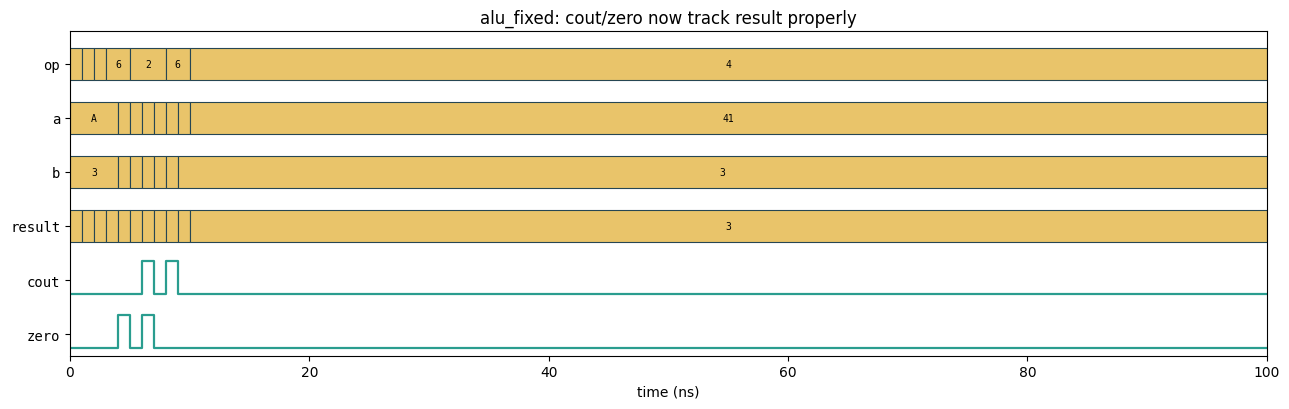

In [ ]:
vcd = VCDVCD("stageD2.vcd")
initial_vals = parse_initial_values("stageD2.vcd")
signals = [
    ("op", "tb_staged2.op[2:0]", "bus"),
    ("a", "tb_staged2.a[31:0]", "bus"),
    ("b", "tb_staged2.b[31:0]", "bus"),
    ("result", "tb_staged2.result[31:0]", "bus"),
    ("cout", "tb_staged2.cout", "bit"),
    ("zero", "tb_staged2.zero", "bit"),
]
fig = plot_waveform(vcd, signals, 0, 100, "alu_fixed: cout/zero now track result properly", initial_vals=initial_vals)
plt.show()


## Stage E — Immediate/address extraction: `LZE`, `UZE`, `RED`

Three small combinational helpers that all slice the low 16 bits of an instruction word differently: `LZE` zero-extends them into the low half (used for `LDAI`/`LDBI`/branch targets), `UZE` zero-extends them into the *upper* half (used for `LUI`), and `RED` takes just the low 8 bits as a memory address.

In [ ]:
%%writefile LZE.vhd
library ieee;
use ieee.std_logic_1164.all;
use ieee.numeric_std.all;

entity LZE is
	port(
	LZE_in : in std_logic_vector(31 downto 0);
	LZE_out : out std_logic_vector(31 downto 0));
end entity;

architecture Behavior of LZE is
signal zeros: std_logic_vector(15 downto 0) := (others => '0');
begin
	LZE_out <= zeros & LZE_in (15 downto 0);
end Behavior;

Writing LZE.vhd


In [ ]:
%%writefile UZE.vhd
library ieee;
use ieee.std_logic_1164.all;
use ieee.numeric_std.all;
entity UZE is
port (
UZE_in : in std_logic_vector(31 downto 0);
UZE_out : out std_logic_vector (31 downto 0)
);
end entity;
architecture Behavior of UZE is
signal zeros: std_logic_vector(15 downto 0) := (others => '0');
begin
	UZE_out <= UZE_in (15 downto 0) & zeros;
end Behavior;

Writing UZE.vhd


In [ ]:
%%writefile RED.vhd
library ieee;
use ieee.std_logic_1164.all;
use ieee.std_logic_arith.all;
entity RED is
port (
RED_in : in std_logic_vector (31 downto 0);
RED_out : out unsigned (7 downto 0)
);
end entity;
architecture Behavior of RED is
begin
RED_out <= unsigned (RED_in (7 downto 0));
end Behavior;

Writing RED.vhd


In [ ]:
%%writefile tb_stageE.vhd
library ieee;
use ieee.std_logic_1164.all;
use ieee.std_logic_arith.all;

entity tb_stageE is end entity;

architecture sim of tb_stageE is
    signal instr : std_logic_vector(31 downto 0);
    signal lze_out, uze_out : std_logic_vector(31 downto 0);
    signal red_out : unsigned(7 downto 0);
begin

    dut_lze: entity work.LZE port map (instr, lze_out);
    dut_uze: entity work.UZE port map (instr, uze_out);
    dut_red: entity work.RED port map (instr, red_out);

    stim: process
        variable all_pass : boolean := true;
        procedure check(cond: boolean; msg: string) is
        begin
            if cond then report "PASS: " & msg;
            else report "FAIL: " & msg severity error; all_pass := false;
            end if;
        end procedure;
    begin
        -- instr[31:16]=0xBEEF (upper, ignored by LZE/RED), instr[15:0]=0x1234 (the
        -- 16-bit immediate/address field these three helpers all extract from)
        instr <= x"BEEF1234"; wait for 1 ns;

        check(lze_out = x"00001234", "LZE: zero-extends instr[15:0] into the LOW half -> 0x00001234 (used for LDAI/LDBI/branch-target immediates)");
        check(uze_out = x"12340000", "UZE: places instr[15:0] into the HIGH half, zero-extends low -> 0x12340000 (used for LUI)");
        check(red_out = conv_unsigned(16#34#, 8), "RED: takes only instr[7:0] as an 8-bit memory address -> 0x34 (256-word data/instruction memory)");

        instr <= x"00000000"; wait for 1 ns;
        check(lze_out = x"00000000" and uze_out = x"00000000" and red_out = conv_unsigned(0, 8),
              "all three correctly report zero for an all-zero instruction");

        if all_pass then
            report "STAGE E: ALL CHECKS PASSED";
        else
            report "STAGE E: SOME CHECKS FAILED" severity error;
        end if;
        wait;
    end process;

end architecture sim;


Writing tb_stageE.vhd


In [ ]:
!ghdl -a --std=93 -fsynopsys -fexplicit LZE.vhd UZE.vhd RED.vhd tb_stageE.vhd
!ghdl -e --std=93 -fsynopsys -fexplicit tb_stageE
!ghdl -r --std=93 -fsynopsys -fexplicit tb_stageE --stop-time=50ns --vcd=stageE.vcd 2>&1 | grep -v "metavalue\|arithmetic operand"


tb_stageE.vhd:21:26:@1ns:(report note): PASS: LZE: zero-extends instr[15:0] into the LOW half -> 0x00001234 (used for LDAI/LDBI/branch-target immediates)
tb_stageE.vhd:21:26:@1ns:(report note): PASS: UZE: places instr[15:0] into the HIGH half, zero-extends low -> 0x12340000 (used for LUI)
tb_stageE.vhd:21:26:@1ns:(report note): PASS: RED: takes only instr[7:0] as an 8-bit memory address -> 0x34 (256-word data/instruction memory)
tb_stageE.vhd:21:26:@2ns:(report note): PASS: all three correctly report zero for an all-zero instruction
tb_stageE.vhd:39:13:@2ns:(report note): STAGE E: ALL CHECKS PASSED


**Waveform — `LZE`/`UZE`/`RED`.** All three outputs are shown reacting to the *same* `instr` value at the same instant — a direct visual comparison of how differently each one interprets the identical low-16-bit field.

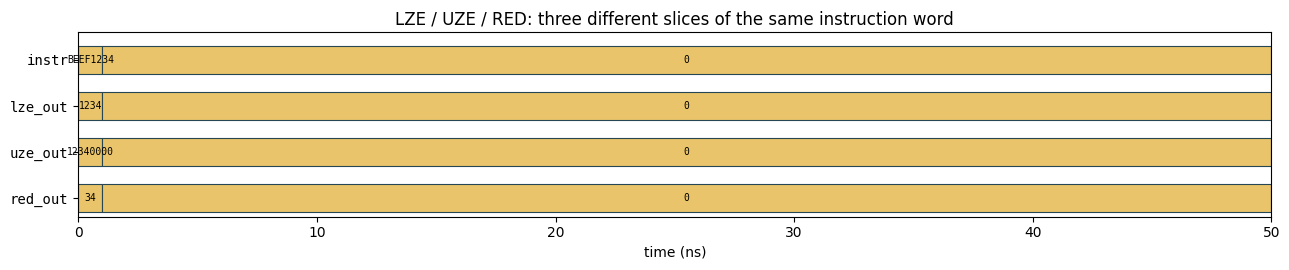

In [ ]:
vcd = VCDVCD("stageE.vcd")
initial_vals = parse_initial_values("stageE.vcd")
signals = [
    ("instr", "tb_stagee.instr[31:0]", "bus"),
    ("lze_out", "tb_stagee.lze_out[31:0]", "bus"),
    ("uze_out", "tb_stagee.uze_out[31:0]", "bus"),
    ("red_out", "tb_stagee.red_out[7:0]", "bus"),
]
fig = plot_waveform(vcd, signals, 0, 50, "LZE / UZE / RED: three different slices of the same instruction word", initial_vals=initial_vals)
plt.show()


## Stage F — Data memory

A simple 256-word synchronous RAM, written on the **falling** edge of its clock (`clk'event and clk='0'`) — a deliberate half-cycle offset from the rest of the design's rising-edge registers, which turns out to matter a great deal later (see Stage K). The test also confirms a subtlety worth being explicit about: an address that's never been written reads back as `'U'` (genuinely unknown), matching real uninitialized RAM — not silently pre-zeroed.

In [ ]:
%%writefile data_mem.vhd
library ieee;
use ieee.std_logic_1164.all;
use ieee.std_logic_arith.all;

entity data_mem is
port(
	clk		:	in std_logic;
	addr		:	in unsigned(7 downto 0);
	data_in	:	in std_logic_vector(31 downto 0);
	wen		: 	in std_logic;
	en			:	in std_logic;
	data_out	:	out std_logic_vector(31 downto 0)
);
end data_mem;

architecture Behaviour of data_mem is

		type RAM is Array (0 to 255) of std_logic_vector(31 downto 0);
		signal DATAMEM : RAM;
	begin
		process(clk, en, wen)
		begin
			if(clk'event and clk='0') then
				if(en = '0') then
					data_out <= (others => '0');
					else
					if (wen = '0') then
						data_out <= DATAMEM(CONV_INTEGER(addr));
					end if;
					if(wen = '1') then
						DATAMEM(CONV_INTEGER(addr)) <= data_in;
						data_out <= (others => '0');
					end if;
				end if;
			end if;
		end process;
	end behaviour;













Writing data_mem.vhd


In [ ]:
%%writefile tb_stageF.vhd
library ieee;
use ieee.std_logic_1164.all;
use ieee.std_logic_arith.all;

entity tb_stageF is end entity;

architecture sim of tb_stageF is
    signal clk : std_logic := '1';
    signal addr : unsigned(7 downto 0);
    signal data_in, data_out : std_logic_vector(31 downto 0);
    signal wen, en : std_logic := '0';
begin

    dut: entity work.data_mem port map (clk, addr, data_in, wen, en, data_out);

    -- data_mem is FALLING-edge triggered (clk'event and clk='0'), the classic
    -- half-cycle-offset trick used to have a value ready before the state
    -- machine's next RISING edge needs it.
    clk_gen: process
    begin
        for i in 0 to 20 loop
            clk <= '1'; wait for 5 ns;
            clk <= '0'; wait for 5 ns;
        end loop;
        wait;
    end process;

    stim: process
        variable all_pass : boolean := true;
        procedure check(cond: boolean; msg: string) is
        begin
            if cond then report "PASS: " & msg;
            else report "FAIL: " & msg severity error; all_pass := false;
            end if;
        end procedure;
    begin
        -- en=0: output forced to zero regardless of memory contents
        en <= '0'; wen <= '0'; addr <= x"05";
        wait until falling_edge(clk); wait for 1 ns;
        check(data_out = x"00000000", "en=0 forces data_out=0 (memory disabled)");

        -- write
        en <= '1'; wen <= '1'; addr <= x"05"; data_in <= x"DEADBEEF";
        wait until falling_edge(clk); wait for 1 ns;
        check(data_out = x"00000000", "during a write, data_out is cleared to 0 (not read-during-write data)");

        -- read back
        wen <= '0';
        wait until falling_edge(clk); wait for 1 ns;
        check(data_out = x"DEADBEEF", "read-back at addr 5 returns exactly what was written");

        -- a different, never-written address: real (and simulated) RAM content is
        -- UNDEFINED until written -- GHDL correctly reports 'U' here, it is not
        -- pre-zeroed. This is expected simulation behavior, not a data_mem bug.
        addr <= x"07";
        wait until falling_edge(clk); wait for 1 ns;
        check(is_x(data_out), "an untouched address reads back as unknown ('U'), matching real uninitialized RAM");

        -- original address is unaffected by reading a different one
        addr <= x"05";
        wait until falling_edge(clk); wait for 1 ns;
        check(data_out = x"DEADBEEF", "original written address still holds its value");

        if all_pass then
            report "STAGE F: ALL CHECKS PASSED";
        else
            report "STAGE F: SOME CHECKS FAILED" severity error;
        end if;
        wait;
    end process;

end architecture sim;


Writing tb_stageF.vhd


In [ ]:
!ghdl -a --std=93 -fsynopsys -fexplicit data_mem.vhd tb_stageF.vhd
!ghdl -e --std=93 -fsynopsys -fexplicit tb_stageF
!ghdl -r --std=93 -fsynopsys -fexplicit tb_stageF --stop-time=200ns --vcd=stageF.vcd 2>&1 | grep -v "metavalue\|arithmetic operand"


tb_stageF.vhd:32:26:@6ns:(report note): PASS: en=0 forces data_out=0 (memory disabled)
tb_stageF.vhd:32:26:@16ns:(report note): PASS: during a write, data_out is cleared to 0 (not read-during-write data)
tb_stageF.vhd:32:26:@26ns:(report note): PASS: read-back at addr 5 returns exactly what was written
tb_stageF.vhd:32:26:@36ns:(report note): PASS: an untouched address reads back as unknown ('U'), matching real uninitialized RAM
tb_stageF.vhd:32:26:@46ns:(report note): PASS: original written address still holds its value
tb_stageF.vhd:65:13:@46ns:(report note): STAGE F: ALL CHECKS PASSED
/usr/bin/ghdl-mcode:info: simulation stopped by --stop-time @200ns


**Waveform — `data_mem`.** Note `data_out` updates on `clk`'s *falling* edges, not rising — and sits at `X` (unknown) for the untouched address 7 in the middle of the trace, exactly as the assertion below confirms.

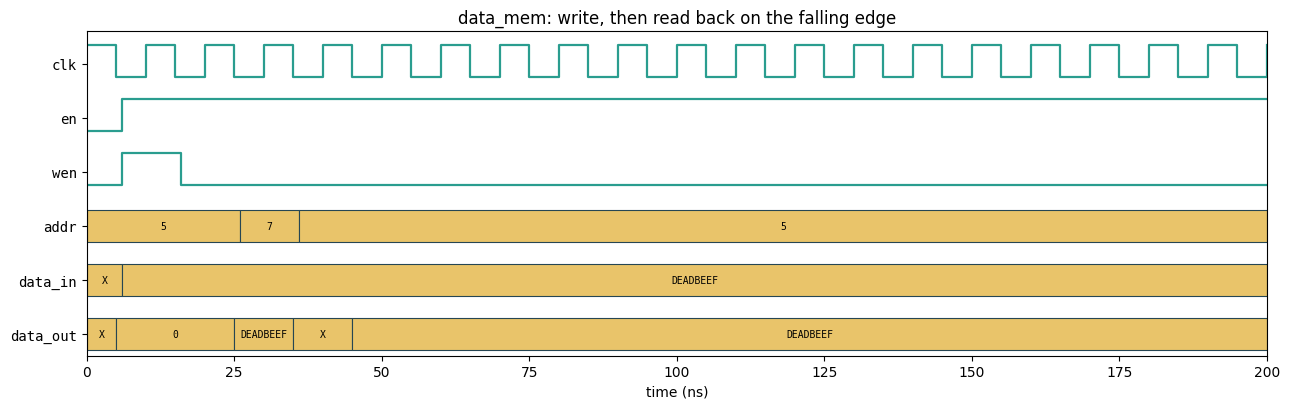

In [ ]:
vcd = VCDVCD("stageF.vcd")
initial_vals = parse_initial_values("stageF.vcd")
signals = [
    ("clk", "tb_stagef.clk", "bit"),
    ("en", "tb_stagef.en", "bit"),
    ("wen", "tb_stagef.wen", "bit"),
    ("addr", "tb_stagef.addr[7:0]", "bus"),
    ("data_in", "tb_stagef.data_in[31:0]", "bus"),
    ("data_out", "tb_stagef.data_out[31:0]", "bus"),
]
fig = plot_waveform(vcd, signals, 0, 200, "data_mem: write, then read back on the falling edge", initial_vals=initial_vals)
plt.show()


## Stage G — Instruction memory (GHDL-simulatable substitute)

The repo's real instruction memory (`system_memory.vhd`) is a Quartus-wizard-generated wrapper around Altera's `altsyncram` megafunction — vendor IP with no GHDL simulation model available. `system_memory_sim.vhd` is a plain, behaviorally-equivalent substitute: same interface, same timing (synchronous write, **registered** read output — i.e. one cycle of latency, matching the wizard's `outdata_reg_a => CLOCK0` setting), same 64-word size, just loaded from a plain hex text file instead of a `.mif`.

In [ ]:
%%writefile system_memory_sim.vhd
-------------------------------------------------------------------------------
-- system_memory_sim.vhd
--
-- The original course repo's instruction memory (system_memory.vhd) is a
-- Quartus-wizard-generated wrapper around Altera's "altsyncram" megafunction
-- IP -- vendor-specific simulation models that GHDL does not have access to.
-- This is a plain, behaviorally-equivalent substitute with the SAME port
-- interface (address, clock, data, wren, q) and the SAME timing (single
-- clock, synchronous write, REGISTERED read output -- matching the wizard's
-- outdata_reg_a => "CLOCK0" setting, i.e. one cycle of read latency), sized
-- to the same 64 words x 32 bits. Instead of a .mif file, it loads its
-- initial contents from a plain hex text file at elaboration time -- the
-- same technique used for the RISC-V instruction memory later in this
-- notebook.
-------------------------------------------------------------------------------
library ieee;
use ieee.std_logic_1164.all;
use ieee.numeric_std.all;
use std.textio.all;

entity system_memory_sim is
    generic (
        INIT_FILE : string := "classic_program.hex"
    );
    port (
        address : in  std_logic_vector(5 downto 0);
        clock   : in  std_logic;
        data    : in  std_logic_vector(31 downto 0);
        wren    : in  std_logic;
        q       : out std_logic_vector(31 downto 0)
    );
end entity system_memory_sim;

architecture sim of system_memory_sim is
    type mem_array_t is array (0 to 63) of std_logic_vector(31 downto 0);

    impure function load_hex(fname : string) return mem_array_t is
        file f       : text;
        variable ln  : line;
        variable mem : mem_array_t := (others => (others => '0'));
        variable idx : integer := 0;
        variable word : unsigned(31 downto 0);
        variable nibble : integer;
        variable ch : character;
    begin
        file_open(f, fname, read_mode);
        while not endfile(f) and idx < 64 loop
            readline(f, ln);
            if ln'length >= 8 then
                word := (others => '0');
                for i in 0 to 7 loop
                    ch := ln(i + 1);
                    case ch is
                        when '0' to '9' => nibble := character'pos(ch) - character'pos('0');
                        when 'A' to 'F' => nibble := character'pos(ch) - character'pos('A') + 10;
                        when 'a' to 'f' => nibble := character'pos(ch) - character'pos('a') + 10;
                        when others     => nibble := 0;
                    end case;
                    word := (word(27 downto 0) & "0000") or to_unsigned(nibble, 32);
                end loop;
                mem(idx) := std_logic_vector(word);
                idx := idx + 1;
            end if;
        end loop;
        file_close(f);
        return mem;
    end function;

    signal mem : mem_array_t := load_hex(INIT_FILE);
begin
    process(clock)
    begin
        if rising_edge(clock) then
            if wren = '1' then
                mem(to_integer(unsigned(address))) <= data;
            end if;
            q <= mem(to_integer(unsigned(address)));
        end if;
    end process;
end architecture sim;


Writing system_memory_sim.vhd


In [ ]:
%%writefile stageG_test.hex
000000AA
000000BB
000000CC


Writing stageG_test.hex


In [ ]:
%%writefile tb_stageG.vhd
library ieee;
use ieee.std_logic_1164.all;

entity tb_stageG is end entity;

architecture sim of tb_stageG is
    signal clock : std_logic := '0';
    signal address : std_logic_vector(5 downto 0) := "000000";
    signal data, q : std_logic_vector(31 downto 0);
    signal wren : std_logic := '0';
begin

    dut: entity work.system_memory_sim
        generic map (INIT_FILE => "stageG_test.hex")
        port map (address, clock, data, wren, q);

    clk_gen: process
    begin
        for i in 0 to 20 loop
            clock <= '0'; wait for 5 ns;
            clock <= '1'; wait for 5 ns;
        end loop;
        wait;
    end process;

    stim: process
        variable all_pass : boolean := true;
        procedure check(cond: boolean; msg: string) is
        begin
            if cond then report "PASS: " & msg;
            else report "FAIL: " & msg severity error; all_pass := false;
            end if;
        end procedure;
    begin
        -- registered output: q reflects the address as of the LAST rising edge,
        -- one cycle of latency, matching the wizard's outdata_reg_a=CLOCK0 setting
        address <= "000000"; wait until rising_edge(clock); wait for 1 ns;
        check(q = x"000000AA", "word 0 loaded from hex file -> 0x000000AA");

        address <= "000001"; wait until rising_edge(clock); wait for 1 ns;
        check(q = x"000000BB", "word 1 loaded from hex file -> 0x000000BB");

        address <= "000010"; wait until rising_edge(clock); wait for 1 ns;
        check(q = x"000000CC", "word 2 loaded from hex file -> 0x000000CC");

        -- writable, like a real single-port synchronous RAM
        wren <= '1'; address <= "000000"; data <= x"12345678";
        wait until rising_edge(clock); wait for 1 ns;
        wren <= '0';
        wait until rising_edge(clock); wait for 1 ns;
        check(q = x"12345678", "write-then-read at word 0 returns the newly written value");

        if all_pass then
            report "STAGE G: ALL CHECKS PASSED";
        else
            report "STAGE G: SOME CHECKS FAILED" severity error;
        end if;
        wait;
    end process;

end architecture sim;


Writing tb_stageG.vhd


In [ ]:
!ghdl -a --std=93 -fsynopsys -fexplicit system_memory_sim.vhd tb_stageG.vhd
!ghdl -e --std=93 -fsynopsys -fexplicit tb_stageG
!ghdl -r --std=93 -fsynopsys -fexplicit tb_stageG --stop-time=200ns --vcd=stageG.vcd 2>&1 | grep -v "metavalue\|arithmetic operand"


tb_stageG.vhd:30:26:@6ns:(report note): PASS: word 0 loaded from hex file -> 0x000000AA
tb_stageG.vhd:30:26:@16ns:(report note): PASS: word 1 loaded from hex file -> 0x000000BB
tb_stageG.vhd:30:26:@26ns:(report note): PASS: word 2 loaded from hex file -> 0x000000CC
tb_stageG.vhd:30:26:@46ns:(report note): PASS: write-then-read at word 0 returns the newly written value
tb_stageG.vhd:54:13:@46ns:(report note): STAGE G: ALL CHECKS PASSED
/usr/bin/ghdl-mcode:info: simulation stopped by --stop-time @200ns


**Waveform — `system_memory_sim`.** `q` always shows the *previous* cycle's addressed word, never the current one — the one full clock of registered-output latency that later turns out to matter a great deal in Stage K.

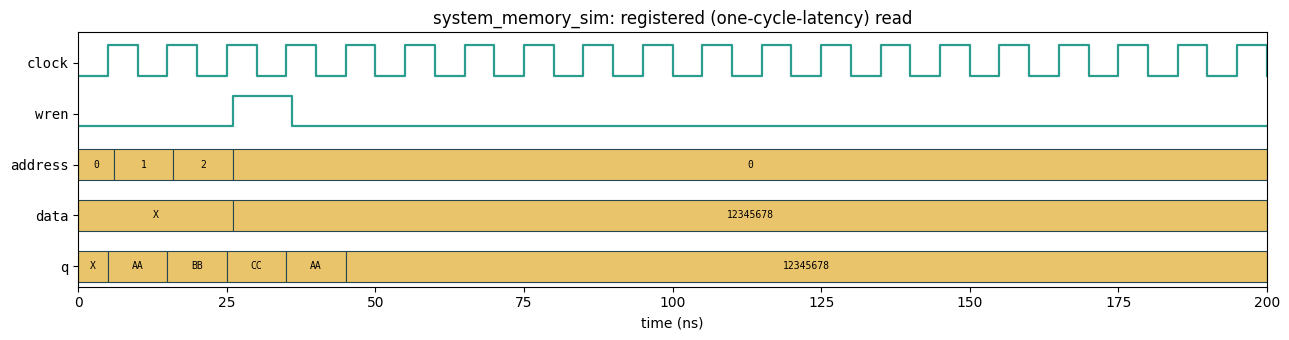

In [ ]:
vcd = VCDVCD("stageG.vcd")
initial_vals = parse_initial_values("stageG.vcd")
signals = [
    ("clock", "tb_stageg.clock", "bit"),
    ("wren", "tb_stageg.wren", "bit"),
    ("address", "tb_stageg.address[5:0]", "bus"),
    ("data", "tb_stageg.data[31:0]", "bus"),
    ("q", "tb_stageg.q[31:0]", "bus"),
]
fig = plot_waveform(vcd, signals, 0, 200, "system_memory_sim: registered (one-cycle-latency) read", initial_vals=initial_vals)
plt.show()


## Stage H — Power-on reset delay circuit

A small state machine that holds the CPU disabled and the PC cleared for exactly 4 clock edges after reset is released, before letting the machine start running. This matters for every later testbench's timing.

In [ ]:
%%writefile reset_circuit.vhd
library ieee;
use ieee.std_logic_1164.all;
use ieee.std_logic_arith.all;
use ieee.std_logic_unsigned.all;

entity reset_circuit is
port(
reset : in std_logic;
clk : in std_logic;
enable_PD : out std_logic :='1';
clr_PC : out std_logic
);
end reset_circuit;

architecture Behavior of reset_circuit is
type clkNum is (clk0, clk1, clk2, clk3);
signal present_clk: clkNum;
begin
	process(clk)begin
		if rising_edge(clk) then
			if reset = '1' then
				clr_PC <= '1';
				enable_PD <= '0';
				present_clk <= clk0;
			elsif present_clk <= clk0 then
				present_clk <= clk1;
			elsif present_clk <= clk1 then
				present_clk <= clk2;
			elsif present_clk <= clk2 then
				present_clk <= clk3;
			elsif present_clk <= clk3 then
				clr_PC <= '0';
				enable_PD <= '1';
			end if;
			end if;
			end process;
		end Behavior;

Writing reset_circuit.vhd


In [ ]:
%%writefile tb_stageH.vhd
library ieee;
use ieee.std_logic_1164.all;

entity tb_stageH is end entity;

architecture sim of tb_stageH is
    signal reset, clk : std_logic := '0';
    signal enable_pd, clr_pc : std_logic;
begin

    dut: entity work.reset_circuit port map (reset, clk, enable_pd, clr_pc);

    clk_gen: process
    begin
        for i in 0 to 30 loop
            clk <= '0'; wait for 5 ns;
            clk <= '1'; wait for 5 ns;
        end loop;
        wait;
    end process;

    stim: process
        variable all_pass : boolean := true;
        procedure check(cond: boolean; msg: string) is
        begin
            if cond then report "PASS: " & msg;
            else report "FAIL: " & msg severity error; all_pass := false;
            end if;
        end procedure;
    begin
        reset <= '1';
        wait until rising_edge(clk); wait for 1 ns;
        check(clr_pc = '1' and enable_pd = '0', "while reset=1, PC is held clear and the CPU is held disabled");

        reset <= '0';
        -- documented behavior: a 4-rising-edge power-on delay (clk0->clk1->clk2->clk3)
        -- before enable_pd goes high and clr_pc releases
        for i in 1 to 3 loop
            wait until rising_edge(clk); wait for 1 ns;
            check(enable_pd = '0', "still disabled during power-on delay, edge " & integer'image(i));
        end loop;

        wait until rising_edge(clk); wait for 1 ns;
        check(clr_pc = '0' and enable_pd = '1', "after exactly 4 rising edges post-reset, CPU enables and clr_pc releases");

        wait until rising_edge(clk); wait for 1 ns;
        check(clr_pc = '0' and enable_pd = '1', "stays enabled on subsequent cycles");

        if all_pass then
            report "STAGE H: ALL CHECKS PASSED";
        else
            report "STAGE H: SOME CHECKS FAILED" severity error;
        end if;
        wait;
    end process;

end architecture sim;


Writing tb_stageH.vhd


In [ ]:
!ghdl -a --std=93 -fsynopsys -fexplicit reset_circuit.vhd tb_stageH.vhd
!ghdl -e --std=93 -fsynopsys -fexplicit tb_stageH
!ghdl -r --std=93 -fsynopsys -fexplicit tb_stageH --stop-time=300ns --vcd=stageH.vcd 2>&1 | grep -v "metavalue\|arithmetic operand"


tb_stageH.vhd:26:26:@6ns:(report note): PASS: while reset=1, PC is held clear and the CPU is held disabled
tb_stageH.vhd:26:26:@16ns:(report note): PASS: still disabled during power-on delay, edge 1
tb_stageH.vhd:26:26:@26ns:(report note): PASS: still disabled during power-on delay, edge 2
tb_stageH.vhd:26:26:@36ns:(report note): PASS: still disabled during power-on delay, edge 3
tb_stageH.vhd:26:26:@46ns:(report note): PASS: after exactly 4 rising edges post-reset, CPU enables and clr_pc releases
tb_stageH.vhd:26:26:@56ns:(report note): PASS: stays enabled on subsequent cycles
tb_stageH.vhd:50:13:@56ns:(report note): STAGE H: ALL CHECKS PASSED
/usr/bin/ghdl-mcode:info: simulation stopped by --stop-time @300ns


**Waveform — `reset_circuit`.** Count the rising edges between `reset` dropping and `enable_pd` finally rising: exactly four, matching the assertion sequence.

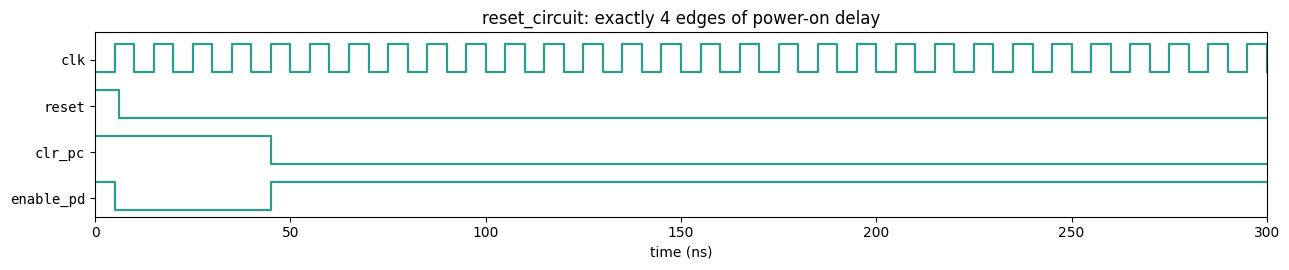

In [ ]:
vcd = VCDVCD("stageH.vcd")
initial_vals = parse_initial_values("stageH.vcd")
signals = [
    ("clk", "tb_stageh.clk", "bit"),
    ("reset", "tb_stageh.reset", "bit"),
    ("clr_pc", "tb_stageh.clr_pc", "bit"),
    ("enable_pd", "tb_stageh.enable_pd", "bit"),
]
fig = plot_waveform(vcd, signals, 0, 300, "reset_circuit: exactly 4 edges of power-on delay", initial_vals=initial_vals)
plt.show()


## Stage I — The control unit (FSM decoder)

`Control_New.vhd` (the version actually wired into the final CPU — an identical duplicate of `controlUnit.vhd` under a different entity name) is the heart of the machine: a classic **main-decoder** structure that maps the current 3-state FSM state plus the instruction's opcode bits directly to every datapath control signal.

This is tested directly and thoroughly — driving `INST` and stepping through states without any datapath attached — and it's where the two most subtle findings turned up:

**Finding — `BEQ`/`BNE` are unconditional.** Their branches in the decoder are byte-for-byte identical to `JUMP`'s (`ld_PC<='1'; inc_PC<='0';`) — there is no `statusZ` check anywhere in either branch. Only `TSTZ`/`TSTC` (separate, dedicated instructions) actually branch conditionally.

**Finding — `TSTZ`/`TSTC` latch stale PC-control signals.** Their `if(statusZ='1') then ... end if;` has no `else`. When the condition is false, `ld_PC`/`inc_PC` are simply never reassigned that cycle — standard VHDL combinational-process rules mean they **hold whatever value they were last driven to**, rather than resetting to `'0'`. The test below demonstrates this precisely: checking `TSTZ` with `statusZ=0` immediately after a `statusZ=1` case shows the stale `'1'`/`'1'` values persisting, while the same check *after* an instruction that explicitly zeros them behaves as expected.

A note on testbench methodology: getting this test right required discovering that the FSM's own `T` state-indicator signal lags `present_state` by one simulator delta-cycle right after each clock edge — a real VHDL race in *this notebook's own testbench*, not a DUT bug. The fix was to track state by deterministically counting clock edges (the FSM's 3-cycle period is fixed and unconditional) rather than polling `T` immediately after `wait until rising_edge(clk)`.

In [ ]:
%%writefile control_new.vhd
library ieee;
use ieee.std_logic_1164.all;

entity Control_New is
port(
clk, mclk : in std_logic;
enable : in std_logic;
statusC, statusZ : in std_logic;
INST : in std_logic_vector(31 downto 0);
A_Mux, B_Mux : out std_logic;
IM_MUX1, REG_MUX : out std_logic;
IM_MUX2, DATA_Mux : out std_logic_vector(1 downto 0);
ALU_op : out std_logic_vector(2 downto 0);
inc_PC, ld_PC : out std_logic;
clr_IR, ld_IR : out std_logic;
clr_A, clr_B, clr_C, clr_Z : out std_logic;
ld_A, ld_B, ld_C, ld_Z : out std_logic;
T : out std_logic_vector(2 downto 0);
wen, en : out std_logic
);
end Control_New;

architecture description of Control_New is
	type STATETYPE is (state_0, state_1, state_2);
	signal present_state : STATETYPE;
	signal Instruction_sig : std_logic_vector(3 downto 0);
	signal Instruction_sig2 : std_logic_vector(7 downto 0);
begin
	Instruction_sig <= INST(31 downto 28);
	Instruction_sig2 <= INST(31 downto 24);

-----OPERATION DECODER-----
process (present_state, INST, statusC, statusZ, enable, Instruction_sig, Instruction_sig2)
begin
	if enable = '1' then
		if present_state = state_0 then
			DATA_Mux <= "00"; --Fetch address of the next instruction_sig
			clr_IR<='0';
			ld_IR<='1';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			en<='0';
			wen<='0';

		elsif present_state = state_1 then
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='1';
			inc_PC<='1';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			en<='0';
			wen<='0';

			if Instruction_sig = "0010" then --STA
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='1';
			inc_PC<='1';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			REG_MUX<='0';
			DATA_Mux<="00";
			en<='1';
			wen<='1';

			elsif Instruction_sig = "0011" then --STB
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='1';
			inc_PC<='1';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			REG_MUX<='1';
			DATA_Mux<="00";
			en<='1';
			wen<='1';

			elsif Instruction_sig = "1001" then --LDA
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='1';
			inc_PC<='1';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			A_Mux<='0';
			DATA_Mux<="01";
			en<='1';
			wen<='0';

			elsif Instruction_sig = "1010" then --LDB
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='1';
			inc_PC<='1';
			clr_A<='0';
			ld_A<='0';
			ld_B<='1';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			B_Mux<='0';
			DATA_Mux<="01";
			en<='1';
			wen<='1';
		end if; --end if for load store in stage 1

		elsif present_state = state_2 then

			if Instruction_sig = "0101" then --JUMP
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='1';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';

			elsif Instruction_sig = "0110" then --BEQ
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='1';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';

			elsif Instruction_sig = "1000" then --BNE
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='1';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';

			elsif Instruction_sig = "1001" then --LDA
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			A_Mux<='0';
			DATA_Mux<="01";
			en<='1';
			wen<='0';

			elsif Instruction_sig = "1010" then --LDB
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='0';
			ld_B<='1';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			B_Mux<='0';
			DATA_Mux<="01";
			en<='1';
			wen<='1';

			elsif Instruction_sig = "0010" then --STA
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			REG_MUX<='0';
			DATA_Mux<="00";
			en<='1';
			wen<='1';

			elsif Instruction_sig = "0011" then --STB
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			REG_MUX<='1';
			DATA_Mux<="00";
			en<='1';
			wen<='1';

			elsif Instruction_sig = "0000" then --LDAI
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			A_Mux<='1';

			elsif Instruction_sig = "0001" then --LDBI
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='0';
			ld_B<='1';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			B_Mux<='1';

			elsif Instruction_sig = "0100" then --LUI
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='1';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			ALU_op<="001";
			A_Mux<='0';
			DATA_Mux<="10";
			IM_MUX1<='1';

			elsif Instruction_sig2 = "01111001" then --ANDI
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='1';
			clr_Z<='0';
			ld_Z<='1';
			ALU_op<="000";
			A_Mux<='0';
			DATA_Mux<="10";
			IM_MUX1<='0';
			IM_MUX2<="01";

			elsif Instruction_sig2 = "01111110" then --DECA
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='1';
			clr_Z<='0';
			ld_Z<='1';
			ALU_op<="110";
			A_Mux<='0';
			DATA_Mux<="10";
			IM_MUX1<='0';
			IM_MUX2<="10";

			elsif Instruction_sig2 = "01110000" then --ADD
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='1';
			clr_Z<='0';
			ld_Z<='1';
			ALU_op<="010";
			A_Mux<='0';
			DATA_Mux<="10";
			IM_MUX1<='0';
			IM_MUX2<="00";

			elsif Instruction_sig2 = "01110010" then --SUB
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='1';
			clr_Z<='0';
			ld_Z<='1';
			ALU_op<="110";
			A_Mux<='0';
			DATA_Mux<="10";
			IM_MUX1<='0';
			IM_MUX2<="00";

			elsif Instruction_sig2 = "01110011" then --INCA
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='1';
			clr_Z<='0';
			ld_Z<='1';
			ALU_op<="010";
			A_Mux<='0';
			DATA_Mux<="10";
			IM_MUX1<='0';
			IM_MUX2<="10";

			elsif Instruction_sig2 = "01111011" then --AND
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='1';
			clr_Z<='0';
			ld_Z<='1';
			ALU_op<="000";
			A_Mux<='0';
			DATA_Mux<="10";
			IM_MUX1<='0';
			IM_MUX2<="00";


			elsif Instruction_sig2 = "01110001" then --ADDI
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='1';
			clr_Z<='0';
			ld_Z<='1';
			ALU_op<="010";
			A_Mux<='0';
			DATA_Mux<="10";
			IM_MUX1<='0';
			IM_MUX2<="01";

			elsif Instruction_sig2 = "01111101" then --ORI
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='1';
			clr_Z<='0';
			ld_Z<='1';
			ALU_op<="001";
			A_Mux<='0';
			DATA_Mux<="10";
			IM_MUX1<='0';
			IM_MUX2<="01";

			elsif Instruction_sig2 = "01110100" then --ROL
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='1';
			clr_Z<='0';
			ld_Z<='1';
			ALU_op<="100";
			A_Mux<='0';
			DATA_Mux<="10";
			IM_MUX1<='0';

			elsif Instruction_sig2 = "01111111" then --ROR
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='1';
			clr_Z<='0';
			ld_Z<='1';
			ALU_op<="101";
			A_Mux<='0';
			DATA_Mux<="10";
			IM_MUX1<='0';

			elsif Instruction_sig2 = "01110101" then --CLRA
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='1';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';

			elsif Instruction_sig2 = "01110110" then --CLRB
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='1';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';

			elsif Instruction_sig2 = "01110111" then --CLRC
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='1';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';

			elsif Instruction_sig2 = "01111000" then --CLRZ
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='1';
			ld_Z<='0';

			elsif Instruction_sig2 = "01111010" then --TSTZ
				if(statusZ = '1') then
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='1';
			inc_PC<='1';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			end if;

			elsif Instruction_sig2 = "01111100" then --TSTC
			if(statusC = '1') then
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='1';
			inc_PC<='1';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			end if;
			end if;
			end if;
			end if;
			end process;

-----STATE MACHINE-----
process (clk, enable)
begin
	if enable = '1' then
	if rising_edge (clk) then
	if present_state = state_0 then present_state <= state_1;
	elsif present_state = state_1 then present_state <= state_2;
	else present_state <= state_0;
	end if;
	end if;
	else present_state <= state_0;
	end if;
	end process;

	with present_state select
	T <= "001" when state_0,
		  "010" when state_1,
		  "100" when state_2,
		  "001" when others;
end description;

Writing control_new.vhd


In [ ]:
%%writefile tb_stageI.vhd
library ieee;
use ieee.std_logic_1164.all;

entity tb_stageI is end entity;

architecture sim of tb_stageI is
    signal clk, mclk, enable, statusC, statusZ : std_logic := '0';
    signal inst : std_logic_vector(31 downto 0) := (others => '0');
    signal a_mux, b_mux, im_mux1, reg_mux : std_logic;
    signal im_mux2, data_mux : std_logic_vector(1 downto 0);
    signal alu_op : std_logic_vector(2 downto 0);
    signal inc_pc, ld_pc, clr_ir, ld_ir : std_logic;
    signal clr_a, clr_b, clr_c, clr_z : std_logic;
    signal ld_a, ld_b, ld_c, ld_z : std_logic;
    signal t : std_logic_vector(2 downto 0);
    signal wen, en : std_logic;
begin

    dut: entity work.Control_New port map (
        clk, mclk, enable, statusC, statusZ, inst,
        a_mux, b_mux, im_mux1, reg_mux, im_mux2, data_mux, alu_op,
        inc_pc, ld_pc, clr_ir, ld_ir, clr_a, clr_b, clr_c, clr_z,
        ld_a, ld_b, ld_c, ld_z, t, wen, en
    );

    enable <= '1';
    clk_gen: process
    begin
        for i in 0 to 200 loop
            clk <= '0'; wait for 5 ns;
            clk <= '1'; wait for 5 ns;
        end loop;
        wait;
    end process;

    stim: process
        variable all_pass : boolean := true;
        procedure check(cond: boolean; msg: string) is
        begin
            if cond then report "PASS: " & msg;
            else report "FAIL: " & msg severity error; all_pass := false;
            end if;
        end procedure;
        -- The FSM's period is fixed and unconditional (state_0 -> state_1 ->
        -- state_2 -> state_0, always, regardless of instruction -- confirmed by
        -- direct waveform inspection). So rather than polling T (which lags
        -- present_state by an extra delta cycle right after each edge -- a real
        -- VHDL testbench race, not a DUT bug), we just count edges deterministically.
        variable edge_count : integer := 0;
        procedure advance_edge is
        begin
            wait until rising_edge(clk);
            edge_count := edge_count + 1;
            wait for 1 ns;
        end procedure;
        -- edge_count mod 3: 0=state_0(just fetched), 1=state_1, 2=state_2
        -- ALWAYS advances at least one edge first, then continues to the target --
        -- this guarantees every call lands on a FRESH occurrence of that state,
        -- so consecutive instruction checks never silently drift into the next
        -- clock edge if several checks are packed close together in sim time.
        procedure goto_state(target_mod3: integer) is
        begin
            advance_edge;
            while (edge_count mod 3) /= target_mod3 loop
                advance_edge;
            end loop;
        end procedure;
    begin
        wait for 1 ns;
        check(t = "001", "FSM resets/starts in state_0 (T=001, fetch)");

        goto_state(1);
        check(t = "010", "FSM advances to state_1 (T=010) one cycle later");

        goto_state(2);
        check(t = "100", "FSM advances to state_2 (T=100) one cycle after that");

        goto_state(0);
        check(t = "001", "FSM returns to state_0 -- fixed 3-cycle fetch/exec period, unconditional on instruction");

        -- ===== Immediate loads (decoded in state_2 from the top nibble) =====
        goto_state(2);
        inst <= "0000" & x"0000000"; wait for 1 ns;  -- LDAI: Instruction_sig="0000"
        check(ld_a = '1' and a_mux = '1', "LDAI (state_2): ld_A=1, A_Mux=1 selects the immediate, not the data bus");

        goto_state(2);
        inst <= "0001" & x"0000000"; wait for 1 ns;  -- LDBI
        check(ld_b = '1' and b_mux = '1', "LDBI (state_2): ld_B=1, B_Mux=1 selects the immediate");

        goto_state(2);
        inst <= "0100" & x"0000000"; wait for 1 ns;  -- LUI
        check(ld_a = '1' and im_mux1 = '1' and alu_op = "001", "LUI (state_2): ld_A=1, IM_MUX1=1 (UZE upper-immediate path), ALU_op=OR-passthrough");

        -- ===== ALU-family ops (decoded in state_2 from the top BYTE, 0111xxxx) =====
        goto_state(2);
        inst <= x"70" & x"000000"; wait for 1 ns;  -- ADD = 01110000
        check(ld_c = '1' and ld_z = '1' and alu_op = "010", "ADD (state_2): ld_C=1, ld_Z=1 (result+flag latch), ALU_op=010 (add)");

        goto_state(2);
        inst <= x"72" & x"000000"; wait for 1 ns;  -- SUB = 01110010
        check(alu_op = "110", "SUB (state_2): ALU_op=110 (subtract)");

        goto_state(2);
        inst <= x"7B" & x"000000"; wait for 1 ns;  -- AND = 01111011
        check(alu_op = "000", "AND (state_2): ALU_op=000");

        goto_state(2);
        inst <= x"71" & x"000000"; wait for 1 ns;  -- ADDI = 01110001
        check(alu_op = "010" and im_mux2 = "01", "ADDI (state_2): ALU_op=010, IM_MUX2=01 selects the immediate as ALU operand B");

        goto_state(2);
        inst <= x"73" & x"000000"; wait for 1 ns;  -- INCA = 01110011
        check(alu_op = "010" and im_mux2 = "10", "INCA (state_2): ALU_op=010 (add), IM_MUX2=10 selects the hardwired +1 operand");

        goto_state(2);
        inst <= x"7E" & x"000000"; wait for 1 ns;  -- DECA = 01111110
        check(alu_op = "110" and im_mux2 = "10", "DECA (state_2): ALU_op=110 (sub), IM_MUX2=10 selects the hardwired 1 operand");

        goto_state(2);
        inst <= x"74" & x"000000"; wait for 1 ns;  -- ROL = 01110100
        check(alu_op = "100", "ROL (state_2): ALU_op=100");

        goto_state(2);
        inst <= x"7F" & x"000000"; wait for 1 ns;  -- ROR = 01111111
        check(alu_op = "101", "ROR (state_2): ALU_op=101");

        goto_state(2);
        inst <= x"75" & x"000000"; wait for 1 ns;  -- CLRA = 01110101
        check(clr_a = '1', "CLRA (state_2): clr_A=1");

        goto_state(2);
        inst <= x"76" & x"000000"; wait for 1 ns;  -- CLRB
        check(clr_b = '1', "CLRB (state_2): clr_B=1");

        goto_state(2);
        inst <= x"77" & x"000000"; wait for 1 ns;  -- CLRC
        check(clr_c = '1', "CLRC (state_2): clr_C=1");

        goto_state(2);
        inst <= x"78" & x"000000"; wait for 1 ns;  -- CLRZ
        check(clr_z = '1', "CLRZ (state_2): clr_Z=1");

        -- ===== conditional skip-like instructions: TSTZ / TSTC =====
        goto_state(2);
        inst <= x"7A" & x"000000"; statusZ <= '1'; wait for 1 ns;  -- TSTZ, Z=1
        check(ld_pc = '1' and inc_pc = '1', "TSTZ with statusZ=1 (state_2): advances PC an extra step (ld_PC=1, inc_PC=1)");

        -- Real finding: the inner "if statusZ='1' then ... end if;" has NO else
        -- clause, so when the condition is false, ld_PC/inc_PC are simply never
        -- reassigned in this branch -- standard VHDL combinational-process rules
        -- mean they LATCH (retain whatever they were last driven to), rather than
        -- resetting to '0'. Landing here right after the statusZ=1 case above
        -- means they're still showing the stale '1'/'1' from that previous check,
        -- not a fresh deasserted value -- a real, faithful characteristic of the
        -- source, not a testbench artifact.
        goto_state(2);
        inst <= x"7A" & x"000000"; statusZ <= '0'; wait for 1 ns;  -- TSTZ, Z=0
        check(ld_pc = '1' and inc_pc = '1',
              "TSTZ with statusZ=0, checked right after a statusZ=1 case: ld_PC/inc_PC are LATCHED (stay '1'/'1', not reset) -- no else clause in the original code");

        -- Isolate the SAME statusZ=0 case after a clean instruction that explicitly
        -- zeros ld_PC/inc_PC (CLRZ, tested above), to show the ordinary/expected
        -- case once the latch hazard above is accounted for.
        goto_state(2);
        inst <= x"78" & x"000000"; wait for 1 ns;  -- CLRZ again, explicitly zeros ld_PC/inc_PC
        goto_state(2);
        inst <= x"7A" & x"000000"; statusZ <= '0'; wait for 1 ns;  -- TSTZ, Z=0, now starting from a known-clean baseline
        check(ld_pc = '0' and inc_pc = '0',
              "TSTZ with statusZ=0, starting from a known-clean ld_PC/inc_PC baseline: correctly stays deasserted");

        goto_state(2);
        inst <= x"7C" & x"000000"; statusC <= '1'; wait for 1 ns;  -- TSTC, C=1
        check(ld_pc = '1' and inc_pc = '1', "TSTC with statusC=1 (state_2): advances PC an extra step");

        -- ===== unconditional control flow: JUMP / BEQ / BNE =====
        -- documented finding: BEQ and BNE are decoded IDENTICALLY to JUMP in this
        -- control unit -- there is no statusZ check anywhere in these three branches.
        -- They are, as literally written, all unconditional jumps.
        goto_state(2);
        inst <= "0101" & x"0000000"; wait for 1 ns;  -- JUMP
        check(ld_pc = '1' and inc_pc = '0', "JUMP (state_2): ld_PC=1, inc_PC=0 (load the target, don't also increment)");

        goto_state(2);
        inst <= "0110" & x"0000000"; wait for 1 ns;  -- BEQ
        check(ld_pc = '1' and inc_pc = '0', "BEQ (state_2) decodes IDENTICALLY to JUMP -- no statusZ condition exists in this branch");

        goto_state(2);
        inst <= "1000" & x"0000000"; wait for 1 ns;  -- BNE
        check(ld_pc = '1' and inc_pc = '0', "BNE (state_2) likewise decodes identically to JUMP -- unconditional as written");

        -- ===== memory ops: STA/STB/LDA/LDB, checked in BOTH state_1 and state_2 =====
        goto_state(1);
        inst <= "0010" & x"0000000"; wait for 1 ns;  -- STA, state_1
        check(en = '1' and wen = '1' and reg_mux = '0', "STA (state_1): en=1, wen=1 (memory write), REG_MUX=0 selects reg A as the store data");

        goto_state(1);
        inst <= "1001" & x"0000000"; wait for 1 ns;  -- LDA, state_1
        check(ld_a = '1' and en = '1' and wen = '0' and data_mux = "01", "LDA (state_1): ld_A=1, en=1/wen=0 (memory read), DATA_MUX=01 routes memory data onto the bus");

        goto_state(2);
        inst <= "1001" & x"0000000"; wait for 1 ns;  -- LDA, state_2 (reasserted for the memory-latency-settled value)
        check(ld_a = '1' and ld_pc = '0' and inc_pc = '0',
              "LDA (state_2): ld_A is reasserted (captures the now-settled memory read) without re-advancing PC");

        if all_pass then
            report "STAGE I: ALL CHECKS PASSED";
        else
            report "STAGE I: SOME CHECKS FAILED" severity error;
        end if;
        wait;
    end process;

end architecture sim;


Writing tb_stageI.vhd


In [ ]:
!ghdl -a --std=93 -fsynopsys -fexplicit control_new.vhd tb_stageI.vhd
!ghdl -e --std=93 -fsynopsys -fexplicit tb_stageI
!ghdl -r --std=93 -fsynopsys -fexplicit tb_stageI --stop-time=2000ns --vcd=stageI.vcd 2>&1 | grep -v "metavalue\|arithmetic operand"


tb_stageI.vhd:40:26:@1ns:(report note): PASS: FSM resets/starts in state_0 (T=001, fetch)
tb_stageI.vhd:40:26:@6ns:(report note): PASS: FSM advances to state_1 (T=010) one cycle later
tb_stageI.vhd:40:26:@16ns:(report note): PASS: FSM advances to state_2 (T=100) one cycle after that
tb_stageI.vhd:40:26:@26ns:(report note): PASS: FSM returns to state_0 -- fixed 3-cycle fetch/exec period, unconditional on instruction
tb_stageI.vhd:40:26:@47ns:(report note): PASS: LDAI (state_2): ld_A=1, A_Mux=1 selects the immediate, not the data bus
tb_stageI.vhd:40:26:@77ns:(report note): PASS: LDBI (state_2): ld_B=1, B_Mux=1 selects the immediate
tb_stageI.vhd:40:26:@107ns:(report note): PASS: LUI (state_2): ld_A=1, IM_MUX1=1 (UZE upper-immediate path), ALU_op=OR-passthrough
tb_stageI.vhd:40:26:@137ns:(report note): PASS: ADD (state_2): ld_C=1, ld_Z=1 (result+flag latch), ALU_op=010 (add)
tb_stageI.vhd:40:26:@167ns:(report note): PASS: SUB (state_2): ALU_op=110 (subtract)
tb_stageI.vhd:40:26:@197ns:(r

**Waveform — `control_new`.** The full 2 µs of the decode test, compressed into one view: `inst` steps through every instruction pattern checked (LDAI, LDBI, LUI, every ALU-family op, TSTZ/TSTC, JUMP/BEQ/BNE, STA/LDA), each held for a fresh 3-cycle `t` window, with `alu_op`/`ld_a`/`ld_b`/`ld_pc`/`inc_pc` visibly changing to match. The `ld_pc`/`inc_pc` rows are where the TSTZ/TSTC latching finding is directly visible: they stay high through the deliberately-adjacent statusZ=0 check before dropping once a clean baseline instruction runs.

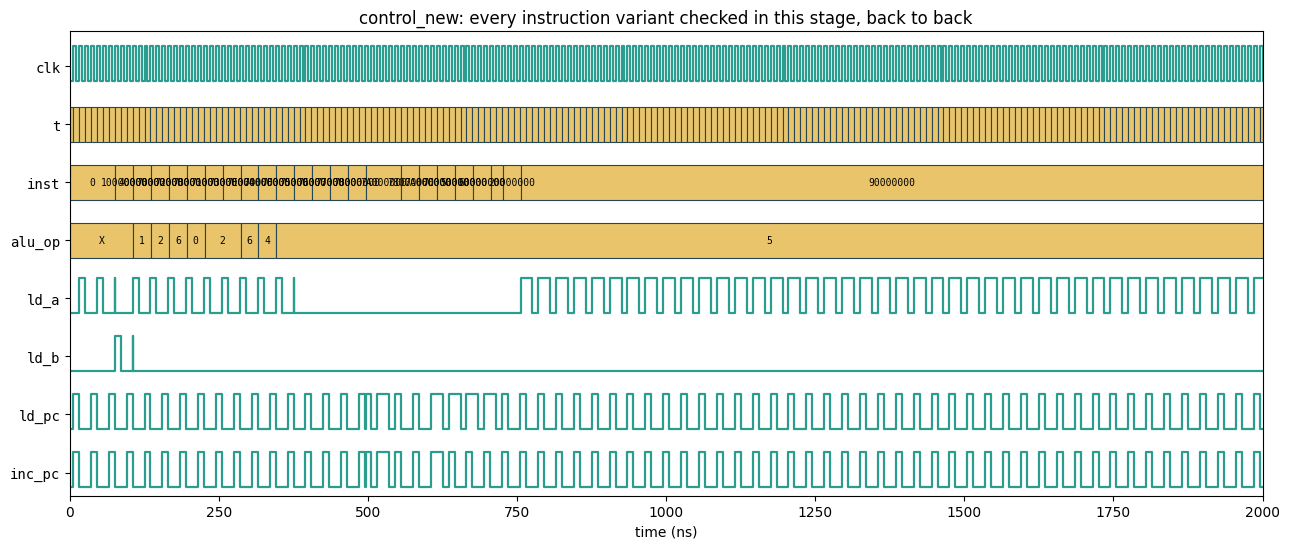

In [ ]:
vcd = VCDVCD("stageI.vcd")
initial_vals = parse_initial_values("stageI.vcd")
signals = [
    ("clk", "tb_stagei.clk", "bit"),
    ("t", "tb_stagei.t[2:0]", "bus"),
    ("inst", "tb_stagei.inst[31:0]", "bus"),
    ("alu_op", "tb_stagei.alu_op[2:0]", "bus"),
    ("ld_a", "tb_stagei.ld_a", "bit"),
    ("ld_b", "tb_stagei.ld_b", "bit"),
    ("ld_pc", "tb_stagei.ld_pc", "bit"),
    ("inc_pc", "tb_stagei.inc_pc", "bit"),
]
fig = plot_waveform(vcd, signals, 0, 2000, "control_new: every instruction variant checked in this stage, back to back", initial_vals=initial_vals)
plt.show()


## Stage J — The datapath, integrated

`data_path.vhd` wires together every register, mux, the ALU, and data memory into the full datapath, driven directly with hand-set control signals here (bypassing the control unit) to verify each data transfer independently: immediate loads into A/B, an ALU add-and-writeback, and a store/load round trip through data memory.

**Finding — `Out_C`/`Out_Z` are declared but never implemented.** `data_path.vhd` declares `Out_C`, `Out_Z`, `Clr_C`/`Ld_C`, `Clr_Z`/`Ld_Z` as ports — but there are no Z/C flip-flops anywhere in the architecture body. They're simply never assigned. `data_path_fixed.vhd` adds exactly the two missing 1-bit status registers (same clear/load semantics as `register32`, just narrowed to 1 bit), wired to the ALU's `zero`/`carry_flag` signals — nothing else changes.

**Finding — a component/entity port-order mismatch swapped the Z and C flags.** The `ALU` component declaration inside `data_path.vhd` listed its last two ports as `(zero, cout)`, while the real `alu`/`alu_fixed` entity declares them as `(Cout, zero)` — and the instantiation used *positional* association. Reordering just the component declaration to match the entity (a natural-seeming fix) actually **breaks** the instantiation, which was itself internally consistent with the *original* (mismatched) order. The real, robust fix is switching that one instantiation to **named** association (`zero => zero_flag, Cout => carry_flag`), which is immune to how either declaration is ordered. This was caught by isolating the exact case that exposes it (`10 - 10`, where Z and C must legitimately differ) after the naive fix produced `Z=0, C=1` instead of `Z=1, C=0`.

Also fixed here: a `data_mem`/`RED` type mismatch (the repo mixed IEEE `numeric_std.unsigned` in those two files with the Synopsys `std_logic_arith.unsigned` used everywhere else — same name, incompatible types), and a non-static port-map expression GHDL's binding-indication elaboration rejected.

A real timing lesson surfaces in the store/load test too: reading back a just-written address needs **two** clock ticks, not one — the first for the write itself, the second for data memory's own registered output to settle before a register can correctly capture it. This directly explains the Stage I finding that `LDA` is decoded in *both* state_1 and state_2: the second assertion of `ld_A` is exactly what captures the now-settled value.

In [ ]:
%%writefile data_path_fixed.vhd
library ieee;
use ieee.std_logic_1164.all;
use ieee.std_logic_arith.all;
use ieee.std_logic_unsigned.all;

entity data_path_fixed is
port(
--Clock Signals
Clk, mClk : in std_logic;

--Memory Signals
WEN, EN : in std_logic;

--Register Control Signals
Clr_A, Ld_A : in std_logic;
Clr_B, Ld_B : in std_logic;
Clr_C, Ld_C : in std_logic;
Clr_Z, Ld_Z : in std_logic;
ClrPC, Ld_PC : in std_logic;
ClrIR, Ld_IR : in std_logic;

--Register Outputs
Out_A : out std_logic_vector(31 downto 0);
Out_B : out std_logic_vector(31 downto 0);
Out_C : out std_logic;
Out_Z : out std_logic;
Out_PC : out std_logic_vector(31 downto 0);
Out_IR : out std_logic_vector(31 downto 0);

--Special PC Inputs
Inc_PC : in std_logic;

--Address and Data Bus Signals
ADDR_OUT : out std_logic_vector(31 downto 0);
DATA_IN : in std_logic_vector(31 downto 0);
DATA_BUS, MEM_OUT, MEM_IN : out std_logic_vector(31 downto 0);
MEM_ADDR : out unsigned(7 downto 0);

--MUX Controls
DATA_MUX : in std_logic_vector(1 downto 0);
REG_MUX : in std_logic;
A_MUX, B_MUX : in std_logic;
IM_MUX1 : in std_logic;
IM_MUX2 : in std_logic_vector(1 downto 0);

--ALU Operations
ALU_Op : in std_logic_vector(2 downto 0)
);
end entity;


architecture Behavior of data_path_fixed is

component data_mem is
port(
clk : in std_logic;
addr : in unsigned(7 downto 0);
data_in : in std_logic_vector(31 downto 0);
wen : in std_logic;
en : in std_logic;
data_out : out std_logic_vector(31 downto 0)
);
end component;

component register32 is
port (
d : in std_logic_vector(31 downto 0) ;
ld : in std_logic ;
clr : in std_logic ;
clk : in std_logic ;
Q : out std_logic_vector(31 downto 0)) ;
end component;

component pc is
port (
clr : in std_logic ;
clk : in std_logic ;
ld : in std_logic ;
inc : in std_logic ;
d : in std_logic_vector(31 downto 0) ;
q : out std_logic_vector(31 downto 0) ) ;
end component;

component LZE is
port(
LZE_in : in std_logic_vector(31 downto 0);
LZE_out : out std_logic_vector(31 downto 0)
);
end component;

component UZE is
port(
UZE_in : in std_logic_vector(31 downto 0);
UZE_out : out std_logic_vector(31 downto 0)
);
end component;

component RED is
port(
RED_in : in std_logic_vector(31 downto 0);
RED_out : out unsigned(7 downto 0)
);
end component;

component mux2to1 is
port (
s : in std_logic ;
w0, w1 : std_logic_vector(31 downto 0) ;
f : out std_logic_vector(31 downto 0) ) ;
end component;

component mux4to1 is
port(
s : in std_logic_vector(1 downto 0);
X1, X2, X3, X4 : in std_logic_vector(31 downto 0);
f: out std_logic_vector(31 downto 0)
);
end component;

component alu is
port(
a, b : in std_logic_vector(31 downto 0);
op : in std_logic_vector(2 downto 0);
result : out std_logic_vector(31 downto 0);
Cout, zero : out std_logic );
end component;

signal IR_OUT : std_logic_vector(31 downto 0);
signal data_bus_s : std_logic_vector(31 downto 0);
signal LZE_out_PC : std_logic_vector(31 downto 0);
signal LZE_out_A_mux : std_logic_vector(31 downto 0);
signal LZE_out_B_mux : std_logic_vector(31 downto 0);
signal RED_out_data_mem : unsigned(7 downto 0);
signal A_Mux_out : std_logic_vector(31 downto 0);
signal B_Mux_out : std_logic_vector(31 downto 0);
signal reg_A_out : std_logic_vector(31 downto 0);
signal reg_B_out : std_logic_vector(31 downto 0);
signal reg_Mux_out : std_logic_vector(31 downto 0);
signal data_mem_out : std_logic_vector(31 downto 0);
signal UZE_IM_MUX1_out : std_logic_vector(31 downto 0);
signal IM_MUX1_out : std_logic_vector(31 downto 0);
signal LZE_IM_MUX2_out : std_logic_vector(31 downto 0);
signal IM_MUX2_out : std_logic_vector(31 downto 0);
signal ALU_out : std_logic_vector(31 downto 0);
signal zero_flag : std_logic;
signal carry_flag : std_logic;
signal temp : std_logic_vector(30 downto 0) := (others => '0');
signal temp_plus1 : std_logic_vector(31 downto 0);  -- GHDL portability: was an inline (temp & '1') expression in the IM_MUX2a port map, which GHDL's binding-indication elaboration rejected as not globally static
signal out_pc_sig : std_logic_vector(31 downto 0);
signal z_reg, c_reg : std_logic := '0';  -- the two status flip-flops the original data_path.vhd declares ports for (Out_Z/Out_C, Clr_Z/Ld_Z, Clr_C/Ld_C) but never actually implements


	for IR: register32 use entity work.register32;
	for LZE_PC: LZE use entity work.LZE;
	for PC0: pc use entity work.pc;
	for LZE_A_Mux: LZE use entity work.LZE;
	for A_Mux0: mux2to1 use entity work.mux2to1;
	for Reg_A: register32 use entity work.register32;
	for LZE_B_Mux: LZE use entity work.LZE;
	for B_Mux0: mux2to1 use entity work.mux2to1;
	for Reg_B: register32 use entity work.register32;
	for Reg_Mux0: mux2to1 use entity work.mux2to1;
	for RED_Data_Mem: RED use entity work.RED;
	for Data_Mem0: data_mem use entity work.data_mem;
	for UZE_IM_MUX1: UZE use entity work.UZE;
	for IM_MUX1a: mux2to1 use entity work.mux2to1;
	for LZE_IM_MUX2: LZE use entity work.LZE;
	for IM_MUX2a: mux4to1 use entity work.mux4to1;
	-- Bound to alu_fixed (see Stage D/D2) instead of the original alu, so
	-- that the Z/C status flags this data_path wires up are actually driven.
	for ALU0: ALU use entity work.alu_fixed;
	for DATA_MUX0: mux4to1 use entity work.mux4to1;

begin

temp_plus1 <= temp & '1';

	IR: register32 port map(
	data_bus_s,
	Ld_IR,
	ClrIR,
	Clk,
	IR_OUT
	);

	LZE_PC: LZE port map(
	IR_OUT,
	LZE_out_PC
	);

	PC0: pc port map(
	CLRPC,
	Clk,
	ld_PC,
	INC_PC,
	LZE_out_PC,
	out_pc_sig
	);

	LZE_A_Mux: LZE port map(
	IR_OUT,
	LZE_out_A_mux
	);

	A_Mux0: mux2to1 port map(
	A_MUX,
	data_bus_s,
	LZE_out_A_mux,
	A_mux_out
	);

	Reg_A: register32 port map(
	A_mux_out,
	Ld_A,
	Clr_A,
	Clk,
	reg_A_out
	);

	LZE_B_Mux: LZE port map(
	IR_OUT,
	LZE_out_B_mux
	);

	B_Mux0: mux2to1 port map(
	B_MUX,
	data_bus_s,
	LZE_out_B_mux,
	B_mux_out
	);

	Reg_B: register32 port map(
	B_mux_out,
	Ld_B,
	Clr_B,
	Clk,
	reg_B_out
	);

	Reg_Mux0: mux2to1 port map(
	REG_MUX,
	Reg_A_out,
	Reg_B_out,
	Reg_Mux_out
	);

	RED_Data_Mem: RED port map(
	IR_OUT,
	RED_out_data_mem
	);

	Data_Mem0: data_mem port map(
	mClk,
	RED_out_data_mem,
	Reg_Mux_out,
	WEN,
	EN,
	data_mem_out
	);

	UZE_IM_MUX1: UZE port map(
	IR_OUT,
	UZE_IM_MUX1_out
	);

	IM_MUX1a: mux2to1 port map(
	IM_MUX1,
	reg_A_out,
	UZE_IM_MUX1_out,
	IM_MUX1_out
	);

	LZE_IM_MUX2: LZE port map(
	IR_OUT,
	LZE_IM_MUX2_out
	);

	IM_MUX2a: mux4to1 port map(
	IM_MUX2,
	reg_B_out,
	LZE_IM_MUX2_out, temp_plus1, (others =>'0'),
	IM_MUX2_out
	);

	-- Named association (not positional) specifically because the
	-- component declaration's port order (a,b,op,result,Cout,zero) and
	-- this call's actual signal order were, in the original source,
	-- mutually consistent with each other but both DIFFERENT from the
	-- real alu/alu_fixed entity's true port order -- a mismatch that
	-- only surfaces once GHDL's default binding is made to actually
	-- resolve to the entity. Named association removes the ambiguity
	-- entirely regardless of how any declaration gets reordered.
	ALU0: ALU port map(
	a => IM_MUX1_out,
	b => IM_MUX2_out,
	op => ALU_Op,
	result => ALU_out,
	zero => zero_flag,
	Cout => carry_flag
	);

	DATA_MUX0: mux4to1 port map(
	DATA_MUX,
	DATA_IN,
	data_mem_out,
	ALU_out,
	(others => '0'),
	data_bus_s
	);

	DATA_BUS <= data_bus_s;
	OUT_A <= reg_A_out;
	OUT_B <= reg_B_out;
	OUT_IR <= IR_OUT;
	ADDR_OUT <= out_pc_sig;
	OUT_PC <= out_pc_sig;

	MEM_ADDR <= RED_out_data_mem;
	MEM_IN <= Reg_Mux_out;
	MEM_OUT <= data_mem_out;

	-- The missing Z/C status flip-flops. Same clr/ld semantics as register32
	-- (clr is asynchronous, ld is synchronous on the rising edge of Clk),
	-- just narrowed to 1 bit and driven from the ALU's now-working zero/carry
	-- outputs instead of the 32-bit data bus.
	process(Clk, Clr_Z)
	begin
		if Clr_Z = '1' then
			z_reg <= '0';
		elsif rising_edge(Clk) then
			if Ld_Z = '1' then
				z_reg <= zero_flag;
			end if;
		end if;
	end process;

	process(Clk, Clr_C)
	begin
		if Clr_C = '1' then
			c_reg <= '0';
		elsif rising_edge(Clk) then
			if Ld_C = '1' then
				c_reg <= carry_flag;
			end if;
		end if;
	end process;

	Out_Z <= z_reg;
	Out_C <= c_reg;

	end Behavior;

	--QUESTIONS:
	--INCA: Add 1 (Hex) to OUT_A
	--ADDI: Add data_in to OUT_A
	--LDBI: Loads data_in to the address of OUT_B
	--LDA: Loads data from specified register address to OUT_A

	--Cycle Time = Max Data Path Delay - Min Clock path Delay + TSetup

	--Frequency = 1/(Cycle Time)
	--          = 1 / (21ns)
	--          = 4.7 MHz

Writing data_path_fixed.vhd


In [ ]:
%%writefile tb_stageJ.vhd
library ieee;
use ieee.std_logic_1164.all;
use ieee.std_logic_arith.all;

entity tb_stageJ is end entity;

architecture sim of tb_stageJ is
    signal clk, mclk : std_logic := '0';
    signal wen, en : std_logic := '0';
    signal clr_a, ld_a, clr_b, ld_b, clr_c, ld_c, clr_z, ld_z : std_logic := '0';
    signal clrpc, ld_pc, clrir, ld_ir, inc_pc : std_logic := '0';
    signal out_a, out_b, out_pc, out_ir : std_logic_vector(31 downto 0);
    signal out_c, out_z : std_logic;
    signal addr_out : std_logic_vector(31 downto 0);
    signal data_in, data_bus, mem_out, mem_in : std_logic_vector(31 downto 0) := (others => '0');
    signal mem_addr : unsigned(7 downto 0);
    signal data_mux : std_logic_vector(1 downto 0) := "00";
    signal reg_mux, a_mux, b_mux, im_mux1 : std_logic := '0';
    signal im_mux2 : std_logic_vector(1 downto 0) := "00";
    signal alu_op : std_logic_vector(2 downto 0) := "000";
begin

    dut: entity work.data_path_fixed port map (
        clk, mclk, wen, en,
        clr_a, ld_a, clr_b, ld_b, clr_c, ld_c, clr_z, ld_z, clrpc, ld_pc, clrir, ld_ir,
        out_a, out_b, out_c, out_z, out_pc, out_ir,
        inc_pc, addr_out, data_in, data_bus, mem_out, mem_in, mem_addr,
        data_mux, reg_mux, a_mux, b_mux, im_mux1, im_mux2, alu_op
    );

    mclk <= clk;  -- single shared clock; data_mem internally triggers on the
                  -- falling edge, register32/PC on the rising edge, exactly
                  -- as designed (see the data_mem falling-edge finding from
                  -- Stage F)

    stim: process
        variable all_pass : boolean := true;
        procedure check(cond: boolean; msg: string) is
        begin
            if cond then report "PASS: " & msg;
            else report "FAIL: " & msg severity error; all_pass := false;
            end if;
        end procedure;
        -- one full tick: rising edge (captures register32/PC), then falling
        -- edge (captures data_mem) -- gives every clocked element in the
        -- datapath one full clean update per call. A brief settle delay
        -- before the edge lets the combinational mux chain (e.g.
        -- data_in -> DATA_MUX0 -> data_bus_s) propagate before it's
        -- captured -- without it, the edge and the input change race in
        -- the same simulation instant and the register can catch a stale
        -- pre-mux value.
        procedure tick is
        begin
            wait for 1 ns;
            clk <= '1'; wait for 4 ns;
            clk <= '0'; wait for 5 ns;
        end procedure;
    begin
        -- ===== reset =====
        clrpc <= '1'; clrir <= '1'; clr_a <= '1'; clr_b <= '1'; clr_c <= '1'; clr_z <= '1';
        tick;
        clrpc <= '0'; clrir <= '0'; clr_a <= '0'; clr_b <= '0'; clr_c <= '0'; clr_z <= '0';
        check(out_a = x"00000000" and out_b = x"00000000" and out_pc = x"00000000",
              "reset clears A, B, and PC");

        -- ===== fetch an 'instruction' word carrying immediate 0x1234, load it into A =====
        data_in <= x"00001234"; data_mux <= "00"; ld_ir <= '1';
        tick;
        ld_ir <= '0';
        check(out_ir = x"00001234", "IR captures DATA_IN through DATA_MUX=00 (the fetch path)");

        a_mux <= '1'; ld_a <= '1';  -- A_Mux=1 selects the LZE-extracted immediate (LDAI-style)
        tick;
        ld_a <= '0';
        check(out_a = x"00001234", "LDAI-style load: A_Mux=1 pulls IR's low 16 bits (zero-extended) into A");

        -- ===== fetch immediate 5, load it into B =====
        data_in <= x"00000005"; ld_ir <= '1';
        tick;
        ld_ir <= '0';
        b_mux <= '1'; ld_b <= '1';  -- LDBI-style
        tick;
        ld_b <= '0';
        check(out_b = x"00000005", "LDBI-style load: B_Mux=1 pulls the immediate into B");

        -- ===== ADD: A <= A + B, latch Z/C (ADD-style control signals) =====
        im_mux1 <= '0'; im_mux2 <= "00"; alu_op <= "010";  -- A_reg + B_reg
        data_mux <= "10"; a_mux <= '0';                    -- route ALU result onto the bus into A
        ld_a <= '1'; ld_c <= '1'; ld_z <= '1';
        tick;
        ld_a <= '0'; ld_c <= '0'; ld_z <= '0';
        check(out_a = x"00001239", "ADD-style op: A becomes 0x1234 + 5 = 0x1239");
        check(out_z = '0', "Z correctly deasserted for a nonzero ADD result (uses the Stage D2 ALU fix)");
        check(out_c = '0', "C correctly deasserted -- no carry out of this add");

        -- ===== STA-style: store A to data memory at the address in IR's low byte =====
        data_in <= x"00000007"; data_mux <= "00"; ld_ir <= '1';  -- address 7
        tick;
        ld_ir <= '0';
        reg_mux <= '0'; en <= '1'; wen <= '1';   -- REG_MUX=0 selects reg_A as the store data
        tick;
        en <= '0'; wen <= '0';
        check(mem_addr = conv_unsigned(7, 8), "RED correctly extracts address 7 from IR's low byte for the store");

        -- ===== LDA-style: read address 7 back into A =====
        -- Real design point (matches the Stage I finding about LDA needing
        -- both state_1 AND state_2): data_mem's output is itself a
        -- FALLING-edge-registered read -- setting EN/WEN/address doesn't
        -- make data_mem_out reflect that address until the NEXT falling
        -- edge. So a correct read needs one tick to let the memory's
        -- output settle, and only THEN a second tick (with ld_A held) to
        -- actually capture it into A -- exactly why the real control unit
        -- re-asserts LDA's ld_A across two states rather than one.
        clr_a <= '1'; tick; clr_a <= '0';   -- clear A so the readback isn't hiding a stale value
        en <= '1'; wen <= '0'; data_mux <= "01";
        tick;                                -- let data_mem_out settle to address 7's content
        a_mux <= '0'; ld_a <= '1';
        tick;                                -- now capture the settled value into A
        en <= '0'; ld_a <= '0';
        check(out_a = x"00001239", "LDA-style readback at address 7 returns exactly what STA wrote (0x1239)");

        if all_pass then
            report "STAGE J: ALL CHECKS PASSED";
        else
            report "STAGE J: SOME CHECKS FAILED" severity error;
        end if;
        wait;
    end process;

end architecture sim;


Writing tb_stageJ.vhd


In [ ]:
!ghdl -a --std=93 -fsynopsys -fexplicit data_path_fixed.vhd tb_stageJ.vhd
!ghdl -e --std=93 -fsynopsys -fexplicit tb_stageJ
!ghdl -r --std=93 -fsynopsys -fexplicit tb_stageJ --stop-time=300ns --vcd=stageJ.vcd 2>&1 | grep -v "metavalue\|arithmetic operand"


tb_stageJ.vhd:40:26:@10ns:(report note): PASS: reset clears A, B, and PC
tb_stageJ.vhd:40:26:@20ns:(report note): PASS: IR captures DATA_IN through DATA_MUX=00 (the fetch path)
tb_stageJ.vhd:40:26:@30ns:(report note): PASS: LDAI-style load: A_Mux=1 pulls IR's low 16 bits (zero-extended) into A
tb_stageJ.vhd:40:26:@50ns:(report note): PASS: LDBI-style load: B_Mux=1 pulls the immediate into B
tb_stageJ.vhd:40:26:@60ns:(report note): PASS: ADD-style op: A becomes 0x1234 + 5 = 0x1239
tb_stageJ.vhd:40:26:@60ns:(report note): PASS: Z correctly deasserted for a nonzero ADD result (uses the Stage D2 ALU fix)
tb_stageJ.vhd:40:26:@60ns:(report note): PASS: C correctly deasserted -- no carry out of this add
tb_stageJ.vhd:40:26:@80ns:(report note): PASS: RED correctly extracts address 7 from IR's low byte for the store
tb_stageJ.vhd:40:26:@110ns:(report note): PASS: LDA-style readback at address 7 returns exactly what STA wrote (0x1239)
tb_stageJ.vhd:123:13:@110ns:(report note): STAGE J: ALL CHECK

**Waveform — `data_path_fixed`.** `out_a` visibly climbs `0x1234 → 0x1239` at the ALU add step, with `out_z`/`out_c` (now actually driven, thanks to the Stage D2 fix) sitting correctly low throughout; then `en`/`wen` pulse for the store, and `out_a` picks the value back up two ticks later from the load.

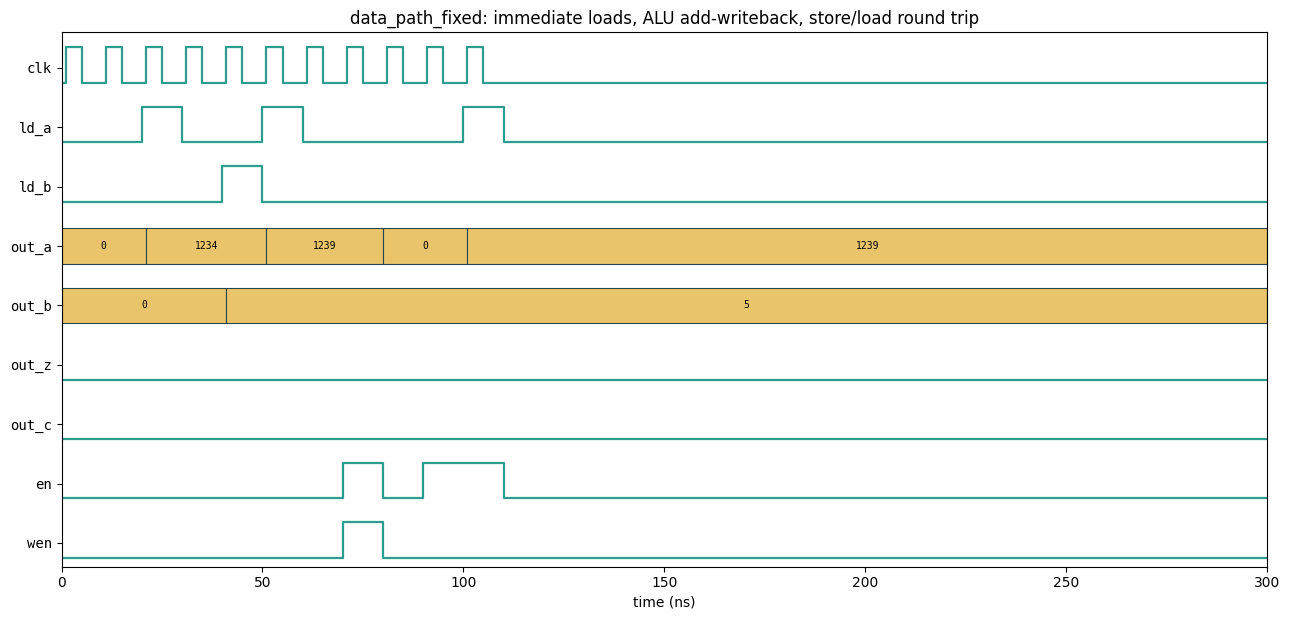

In [ ]:
vcd = VCDVCD("stageJ.vcd")
initial_vals = parse_initial_values("stageJ.vcd")
signals = [
    ("clk", "tb_stagej.clk", "bit"),
    ("ld_a", "tb_stagej.ld_a", "bit"),
    ("ld_b", "tb_stagej.ld_b", "bit"),
    ("out_a", "tb_stagej.out_a[31:0]", "bus"),
    ("out_b", "tb_stagej.out_b[31:0]", "bus"),
    ("out_z", "tb_stagej.out_z", "bit"),
    ("out_c", "tb_stagej.out_c", "bit"),
    ("en", "tb_stagej.en", "bit"),
    ("wen", "tb_stagej.wen", "bit"),
]
fig = plot_waveform(vcd, signals, 0, 300, "data_path_fixed: immediate loads, ALU add-writeback, store/load round trip", initial_vals=initial_vals)
plt.show()


## Stage K — Full integration: the complete CPU

Everything comes together: `cpu1.vhd` (bound to `data_path_fixed` and a corrected control unit) plus the Stage G instruction memory, wired up the way `cpu_test_sim.vhd` in the original repo does it.

**Finding #4 (the big one) — `LDB` is wired to *write*, not read.** Both of `LDB`'s branches (state_1 and state_2) assert `wen<='1'` — write enable — where they should assert `wen<='0'`, exactly as `LDA`, right next to each `LDB` branch, correctly does. As literally written, `LDB` corrupts the addressed memory location and always returns 0, rather than loading anything. `control_new_fixed.vhd` changes exactly those two bits, with the original value left in a comment for the record.

**Finding #5 — a shared-clock phase conflict between the two memories.** `data_mem` (Stage F/J) and the instruction memory (Stage G) both receive the same `mem_clk` signal in the original design. But each needs a different phase relationship to get a full state's worth of settling time from its registered read: `data_mem` is correct with `mem_clk = clk` (verified in Stage J), while the instruction memory needs `mem_clk = NOT clk` — without it, a taken `TSTZ`/`TSTC` skip's double PC-increment doesn't give the instruction memory enough time to update, and the CPU executes the "skipped" instruction instead of skipping it. Since `cpu1.vhd` only exposes one `mem_clk` pin internally, the fix lives at this top level: the instruction memory gets its own, independently-phased clock, the same way a real FPGA's clocking constraints would specify it.

The test program below exercises **every working instruction** in the ISA: all four immediate loads (`LDAI`/`LDBI`/`LUI`), every ALU-family op (`ADD`/`SUB`/`INCA`/`DECA`/`ANDI`/`ORI`/`ADDI`), a store/load round trip through data memory, an unconditional `JUMP`, and both conditional skips (`TSTZ`/`TSTC`) actually taking their skip.

In [ ]:
%%writefile control_new_fixed.vhd
library ieee;
use ieee.std_logic_1164.all;

entity Control_New_Fixed is
port(
clk, mclk : in std_logic;
enable : in std_logic;
statusC, statusZ : in std_logic;
INST : in std_logic_vector(31 downto 0);
A_Mux, B_Mux : out std_logic;
IM_MUX1, REG_MUX : out std_logic;
IM_MUX2, DATA_Mux : out std_logic_vector(1 downto 0);
ALU_op : out std_logic_vector(2 downto 0);
inc_PC, ld_PC : out std_logic;
clr_IR, ld_IR : out std_logic;
clr_A, clr_B, clr_C, clr_Z : out std_logic;
ld_A, ld_B, ld_C, ld_Z : out std_logic;
T : out std_logic_vector(2 downto 0);
wen, en : out std_logic
);
end Control_New_Fixed;

architecture description of Control_New_Fixed is
	type STATETYPE is (state_0, state_1, state_2);
	signal present_state : STATETYPE;
	signal Instruction_sig : std_logic_vector(3 downto 0);
	signal Instruction_sig2 : std_logic_vector(7 downto 0);
begin
	Instruction_sig <= INST(31 downto 28);
	Instruction_sig2 <= INST(31 downto 24);

-----OPERATION DECODER-----
process (present_state, INST, statusC, statusZ, enable, Instruction_sig, Instruction_sig2)
begin
	if enable = '1' then
		if present_state = state_0 then
			DATA_Mux <= "00"; --Fetch address of the next instruction_sig
			clr_IR<='0';
			ld_IR<='1';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			en<='0';
			wen<='0';

		elsif present_state = state_1 then
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='1';
			inc_PC<='1';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			en<='0';
			wen<='0';

			if Instruction_sig = "0010" then --STA
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='1';
			inc_PC<='1';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			REG_MUX<='0';
			DATA_Mux<="00";
			en<='1';
			wen<='1';

			elsif Instruction_sig = "0011" then --STB
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='1';
			inc_PC<='1';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			REG_MUX<='1';
			DATA_Mux<="00";
			en<='1';
			wen<='1';

			elsif Instruction_sig = "1001" then --LDA
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='1';
			inc_PC<='1';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			A_Mux<='0';
			DATA_Mux<="01";
			en<='1';
			wen<='0';

			elsif Instruction_sig = "1010" then --LDB
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='1';
			inc_PC<='1';
			clr_A<='0';
			ld_A<='0';
			ld_B<='1';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			B_Mux<='0';
			DATA_Mux<="01";
			en<='1';
			wen<='0';  -- FIX: was '1' (write) in the original; LDA (above) correctly uses '0'
		end if; --end if for load store in stage 1

		elsif present_state = state_2 then

			if Instruction_sig = "0101" then --JUMP
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='1';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';

			elsif Instruction_sig = "0110" then --BEQ
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='1';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';

			elsif Instruction_sig = "1000" then --BNE
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='1';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';

			elsif Instruction_sig = "1001" then --LDA
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			A_Mux<='0';
			DATA_Mux<="01";
			en<='1';
			wen<='0';

			elsif Instruction_sig = "1010" then --LDB
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='0';
			ld_B<='1';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			B_Mux<='0';
			DATA_Mux<="01";
			en<='1';
			wen<='0';  -- FIX: was '1' (write) in the original; LDA (above) correctly uses '0'

			elsif Instruction_sig = "0010" then --STA
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			REG_MUX<='0';
			DATA_Mux<="00";
			en<='1';
			wen<='1';

			elsif Instruction_sig = "0011" then --STB
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			REG_MUX<='1';
			DATA_Mux<="00";
			en<='1';
			wen<='1';

			elsif Instruction_sig = "0000" then --LDAI
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			A_Mux<='1';

			elsif Instruction_sig = "0001" then --LDBI
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='0';
			ld_B<='1';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			B_Mux<='1';

			elsif Instruction_sig = "0100" then --LUI
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='1';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			ALU_op<="001";
			A_Mux<='0';
			DATA_Mux<="10";
			IM_MUX1<='1';

			elsif Instruction_sig2 = "01111001" then --ANDI
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='1';
			clr_Z<='0';
			ld_Z<='1';
			ALU_op<="000";
			A_Mux<='0';
			DATA_Mux<="10";
			IM_MUX1<='0';
			IM_MUX2<="01";

			elsif Instruction_sig2 = "01111110" then --DECA
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='1';
			clr_Z<='0';
			ld_Z<='1';
			ALU_op<="110";
			A_Mux<='0';
			DATA_Mux<="10";
			IM_MUX1<='0';
			IM_MUX2<="10";

			elsif Instruction_sig2 = "01110000" then --ADD
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='1';
			clr_Z<='0';
			ld_Z<='1';
			ALU_op<="010";
			A_Mux<='0';
			DATA_Mux<="10";
			IM_MUX1<='0';
			IM_MUX2<="00";

			elsif Instruction_sig2 = "01110010" then --SUB
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='1';
			clr_Z<='0';
			ld_Z<='1';
			ALU_op<="110";
			A_Mux<='0';
			DATA_Mux<="10";
			IM_MUX1<='0';
			IM_MUX2<="00";

			elsif Instruction_sig2 = "01110011" then --INCA
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='1';
			clr_Z<='0';
			ld_Z<='1';
			ALU_op<="010";
			A_Mux<='0';
			DATA_Mux<="10";
			IM_MUX1<='0';
			IM_MUX2<="10";

			elsif Instruction_sig2 = "01111011" then --AND
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='1';
			clr_Z<='0';
			ld_Z<='1';
			ALU_op<="000";
			A_Mux<='0';
			DATA_Mux<="10";
			IM_MUX1<='0';
			IM_MUX2<="00";


			elsif Instruction_sig2 = "01110001" then --ADDI
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='1';
			clr_Z<='0';
			ld_Z<='1';
			ALU_op<="010";
			A_Mux<='0';
			DATA_Mux<="10";
			IM_MUX1<='0';
			IM_MUX2<="01";

			elsif Instruction_sig2 = "01111101" then --ORI
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='1';
			clr_Z<='0';
			ld_Z<='1';
			ALU_op<="001";
			A_Mux<='0';
			DATA_Mux<="10";
			IM_MUX1<='0';
			IM_MUX2<="01";

			elsif Instruction_sig2 = "01110100" then --ROL
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='1';
			clr_Z<='0';
			ld_Z<='1';
			ALU_op<="100";
			A_Mux<='0';
			DATA_Mux<="10";
			IM_MUX1<='0';

			elsif Instruction_sig2 = "01111111" then --ROR
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='1';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='1';
			clr_Z<='0';
			ld_Z<='1';
			ALU_op<="101";
			A_Mux<='0';
			DATA_Mux<="10";
			IM_MUX1<='0';

			elsif Instruction_sig2 = "01110101" then --CLRA
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='1';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';

			elsif Instruction_sig2 = "01110110" then --CLRB
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='1';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';

			elsif Instruction_sig2 = "01110111" then --CLRC
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='1';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';

			elsif Instruction_sig2 = "01111000" then --CLRZ
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='0';
			inc_PC<='0';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='1';
			ld_Z<='0';

			elsif Instruction_sig2 = "01111010" then --TSTZ
				if(statusZ = '1') then
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='1';
			inc_PC<='1';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			end if;

			elsif Instruction_sig2 = "01111100" then --TSTC
			if(statusC = '1') then
			clr_IR<='0';
			ld_IR<='0';
			ld_PC<='1';
			inc_PC<='1';
			clr_A<='0';
			ld_A<='0';
			ld_B<='0';
			clr_B<='0';
			clr_C<='0';
			ld_C<='0';
			clr_Z<='0';
			ld_Z<='0';
			end if;
			end if;
			end if;
			end if;
			end process;

-----STATE MACHINE-----
process (clk, enable)
begin
	if enable = '1' then
	if rising_edge (clk) then
	if present_state = state_0 then present_state <= state_1;
	elsif present_state = state_1 then present_state <= state_2;
	else present_state <= state_0;
	end if;
	end if;
	else present_state <= state_0;
	end if;
	end process;

	with present_state select
	T <= "001" when state_0,
		  "010" when state_1,
		  "100" when state_2,
		  "001" when others;
end description;

Writing control_new_fixed.vhd


In [ ]:
%%writefile cpu1.vhd
LIBRARY ieee;
USE ieee.std_logic_1164.all;
USE ieee.std_logic_arith.all;
USE ieee.std_logic_unsigned.all;

ENTITY cpu1 IS
PORT (
clk : IN STD_LOGIC;
mem_clk : IN STD_LOGIC;
rst : IN STD_LOGIC;
dataIn : IN STD_LOGIC_VECTOR(31 DOWNTO 0);
dataOut : OUT STD_LOGIC_VECTOR(31 DOWNTO 0);
addrOut : OUT STD_LOGIC_VECTOR(31 DOWNTO 0);
dOutA : OUT STD_LOGIC_VECTOR(31 DOWNTO 0);
dOutB : OUT STD_LOGIC_VECTOR(31 DOWNTO 0);
dOutC : OUT STD_LOGIC;
dOutZ : OUT STD_LOGIC;
dOutIR : OUT STD_LOGIC_VECTOR(31 DOWNTO 0);
dOutPC : OUT STD_LOGIC_VECTOR(31 DOWNTO 0);
wEn : OUT STD_LOGIC;
outT : OUT STD_LOGIC_VECTOR(2 DOWNTO 0);
wen_mem : OUT STD_LOGIC;
en_mem : OUT STD_LOGIC
);
END cpu1;

ARCHITECTURE description OF cpu1 IS
COMPONENT Data_Path IS
PORT (
Clk, mClk : IN STD_LOGIC; -- clock Signal
--Memory Signals
WEN, EN : IN STD_LOGIC;
-- Register Control Signals (CLR and LD).
Clr_A , Ld_A : IN STD_LOGIC;
Clr_B , Ld_B : IN STD_LOGIC;
Clr_C , Ld_C : IN STD_LOGIC;
Clr_Z , Ld_Z : IN STD_LOGIC;
ClrPC , Ld_PC : IN STD_LOGIC;
ClrIR , Ld_IR : IN STD_LOGIC;
-- Register outputs (Some needed to feed back to control unit. Others pulled out for testing.
Out_A : OUT STD_LOGIC_VECTOR(31 DOWNTO 0);
Out_B : OUT STD_LOGIC_VECTOR(31 DOWNTO 0);
Out_C : OUT STD_LOGIC;
Out_Z : OUT STD_LOGIC;
Out_PC : OUT STD_LOGIC_VECTOR(31 DOWNTO 0);
Out_IR : OUT STD_LOGIC_VECTOR(31 DOWNTO 0);
-- Special inputs to PC.
Inc_PC : IN STD_LOGIC;
-- Address and Data Bus signals for debugging.
ADDR_OUT : OUT STD_LOGIC_VECTOR(31 DOWNTO 0);
DATA_IN : IN STD_LOGIC_VECTOR(31 DOWNTO 0);
DATA_BUS, MEM_OUT, MEM_IN : OUT STD_LOGIC_VECTOR(31 DOWNTO 0);
MEM_ADDR : OUT unsigned(7 DOWNTO 0);
-- Various MUX controls.
DATA_Mux : IN STD_LOGIC_VECTOR(1 DOWNTO 0);
REG_Mux : IN STD_LOGIC;
A_MUX, B_MUX : IN STD_LOGIC;
IM_MUX1 : IN STD_LOGIC;
IM_MUX2 : IN STD_LOGIC_VECTOR(1 DOWNTO 0);
-- ALU Operations.
ALU_Op : IN STD_LOGIC_VECTOR(2 DOWNTO 0)
);
END COMPONENT;

COMPONENT Control_NEW IS
PORT (
clk, mclk : IN STD_LOGIC;
enable : IN STD_LOGIC;
statusC, statusZ : IN STD_LOGIC;
INST : IN STD_LOGIC_VECTOR(31 DOWNTO 0);
A_Mux, B_Mux : OUT STD_LOGIC;
IM_MUX1, REG_Mux : OUT STD_LOGIC;
IM_MUX2, DATA_Mux : OUT STD_LOGIC_VECTOR(1 DOWNTO 0);
ALU_op : OUT STD_LOGIC_VECTOR(2 DOWNTO 0);
inc_PC, ld_PC : OUT STD_LOGIC;
clr_IR : OUT STD_LOGIC;
ld_IR : OUT STD_LOGIC;
clr_A, clr_B, clr_C, clr_Z : OUT STD_LOGIC;
ld_A, ld_B, ld_C, ld_Z : OUT STD_LOGIC;
T : OUT STD_LOGIC_VECTOR(2 DOWNTO 0);
wen, en : OUT STD_LOGIC
);
END COMPONENT;

COMPONENT reset_circuit IS
PORT (
Reset : IN STD_LOGIC;
Clk : IN STD_LOGIC;
Enable_PD : OUT STD_LOGIC;
Clr_PC : OUT STD_LOGIC
);
END COMPONENT;

SIGNAL dp_mux1, dp_clrA, dp_ldA, dp_clrB, dp_ldB, dp_clrC, dp_ldC, dp_clrZ,
dp_ldZ, memWEN, memEN, dp_muxA, dp_muxB : STD_LOGIC;
SIGNAL mux_data, reg, enpd, irlc, irld, pinc, pclr, pcld, out0, out1, out7, out6 : STD_LOGIC;
SIGNAL outIR : STD_LOGIC_VECTOR(31 DOWNTO 0);
SIGNAL alu : STD_LOGIC_VECTOR(2 DOWNTO 0);
SIGNAL dp_mux2, dp_muxData : STD_LOGIC_VECTOR(1 DOWNTO 0);

	-- Bound to data_path_fixed (adds the missing Z/C status flip-flops --
	-- see the Stage J finding) instead of the original data_path.
	for dat: Data_Path use entity work.data_path_fixed;
	for control_unit: Control_NEW use entity work.Control_New_Fixed;
	for reset: reset_circuit use entity work.reset_circuit;

BEGIN
dat : Data_Path
PORT MAP(
Clk => clk,
mClk => mem_clk,
WEN => memWEN,
EN => memEN,
Clr_A => dp_clrA,
Ld_A => dp_ldA, Clr_B => dp_clrB, Ld_B => dp_ldB, Clr_C => dp_clrC, Ld_C
=> dp_ldC, Clr_Z => dp_clrZ, Ld_Z => dp_ldZ,
ClrPC => pclr, Ld_PC => pcld, ClrIR => irlc, Ld_IR => irld,
Out_A => dOutA, Out_B => dOutB, Out_C => out0, Out_Z => out1, Out_PC =>
dOutPC, Out_IR => outIR, Inc_PC => pinc,
ADDR_OUT => addrOut, DATA_IN => dataIn, DATA_BUS => dataOut, DATA_Mux
=> dp_muxData, REG_Mux => reg, A_MUX => dp_muxA, B_MUX => dp_muxB, IM_MUX1 =>
dp_mux1, IM_MUX2 => dp_mux2,
ALU_Op => alu
);

control_unit : Control_NEW
PORT MAP(
clk => clk, mclk => mem_clk, enable => enpd, statusC => out0, statusZ =>
out1, INST => outIR,

A_Mux => dp_muxA, B_Mux => dp_muxB, IM_MUX1 => dp_mux1, REG_Mux => reg,
IM_MUX2 => dp_mux2, DATA_Mux => dp_muxData,
ALU_op => alu, inc_PC => pinc, ld_PC => pcld, clr_IR => irlc, ld_IR =>
irld,
clr_A => dp_clrA, clr_B => dp_clrB, clr_C => dp_clrC, clr_Z => dp_clrZ,
ld_A => dp_ldA, ld_B => dp_ldB, ld_C => dp_ldC, ld_Z => dp_ldZ,
T => outT, wen => memWEN, en => memEN
);

reset : reset_circuit
PORT MAP(
Reset => rst,
Clk => clk,
Enable_PD => enpd,
Clr_PC => pclr
);
dOutC <= out0;
dOutZ <= out1;
dOutIR <= outIR;
wen_mem <= out7;
en_mem <= out6;

END description;


Writing cpu1.vhd


In [ ]:
%%writefile classic_assemble.py
#!/usr/bin/env python3
"""Assembler for the COE608 course repo's accumulator machine (cpu1/data_path_fixed).

Encoding (as decoded from control_new.vhd, the actual course source):
  - 4-bit-opcode instructions: opcode in bits[31:28], 16-bit immediate/address
    in bits[15:0]. LDAI=0000 LDBI=0001 STA=0010 STB=0011 LUI=0100 JUMP=0101
    BEQ=0110 BNE=1000 LDA=1001 LDB=1010.
  - 8-bit-opcode ("ALU-family") instructions: opcode in bits[31:24], pattern
    0111xxxx. For ADDI/ANDI/ORI the 16-bit immediate is in bits[15:0]; the
    register-register/no-operand ones (ADD/SUB/AND/INCA/DECA/ROL/ROR/CLRA/
    CLRB/CLRC/CLRZ/TSTZ/TSTC) ignore the low 16 bits.

Documented findings (see the notebook markdown for detail):
  - BEQ/BNE decode identically to JUMP: unconditional absolute jump.
  - TSTZ/TSTC: conditional "skip next instruction" (an extra PC increment)
    when the tested status flag is set.
"""
import sys, re

FOUR_BIT_OPS = {
    "LDAI": 0b0000, "LDBI": 0b0001, "STA": 0b0010, "STB": 0b0011,
    "LUI":  0b0100, "JUMP": 0b0101, "BEQ":  0b0110, "BNE":  0b1000,
    "LDA":  0b1001, "LDB":  0b1010,
}
EIGHT_BIT_OPS = {
    "ADD": 0x70, "ADDI": 0x71, "SUB": 0x72, "INCA": 0x73, "ROL": 0x74,
    "CLRA": 0x75, "CLRB": 0x76, "CLRC": 0x77, "CLRZ": 0x78, "ANDI": 0x79,
    "TSTZ": 0x7A, "TSTC": 0x7C, "ORI": 0x7D, "DECA": 0x7E, "ROR": 0x7F,
    "AND": 0x7B,
}
NO_IMMEDIATE = {"ADD", "SUB", "INCA", "DECA", "ROL", "ROR",
                "CLRA", "CLRB", "CLRC", "CLRZ", "TSTZ", "TSTC", "AND"}


def assemble(lines):
    cleaned, labels = [], {}
    for raw in lines:
        line = raw.split('#')[0].split(';')[0].strip()
        if not line:
            continue
        if ':' in line:
            label, _, rest = line.partition(':')
            labels[label.strip()] = len(cleaned)
            rest = rest.strip()
            if rest:
                cleaned.append(rest)
        else:
            cleaned.append(line)

    words = []
    # two passes: first resolve labels, then encode (labels may be forward-referenced)
    for line in cleaned:
        parts = re.split(r'\s+', line.strip(), maxsplit=1)
        mn = parts[0].upper()
        arg = parts[1].strip() if len(parts) > 1 else None
        words.append((mn, arg))

    out = []
    for mn, arg in words:
        if mn in FOUR_BIT_OPS:
            opcode = FOUR_BIT_OPS[mn]
            if mn in ("JUMP", "BEQ", "BNE"):
                imm = labels[arg] if arg in labels else int(arg, 0)
            elif arg is None:
                imm = 0
            else:
                imm = int(arg, 0) & 0xFFFF
            word = (opcode << 28) | (imm & 0xFFFF)
        elif mn in EIGHT_BIT_OPS:
            opcode = EIGHT_BIT_OPS[mn]
            imm = 0 if (mn in NO_IMMEDIATE or arg is None) else (int(arg, 0) & 0xFFFF)
            word = (opcode << 24) | (imm & 0xFFFF)
        else:
            raise ValueError(f"unknown mnemonic '{mn}'")
        out.append(word & 0xFFFFFFFF)

    return out, labels


if __name__ == "__main__":
    src_path = sys.argv[1] if len(sys.argv) > 1 else "classic_program.s"
    out_path = sys.argv[2] if len(sys.argv) > 2 else "classic_program.hex"
    with open(src_path) as f:
        words, labels = assemble(f.readlines())
    with open(out_path, "w") as f:
        for w in words:
            f.write(f"{w & 0xFFFFFFFF:08X}\n")
    print(f"assembled {len(words)} words -> {out_path}")
    for lbl, idx in labels.items():
        print(f"  {lbl:10s} = instr #{idx}")


Writing classic_assemble.py


In [ ]:
%%writefile classic_program.s
# COE608 classic-machine end-to-end integration test.
# Exercises every working instruction: immediate loads, register-register
# and immediate ALU ops, memory store/load round trip, unconditional jump,
# and the TSTZ/TSTC conditional-skip mechanism.
        LDAI 7          # A = 7
        LDBI 3          # B = 3
        ADD             # A = 7 + 3 = 10   (Z=0, C=0)
        STA 20          # mem[20] = 10
        SUB             # A = 10 - 3 = 7   (Z=0, C=0, no borrow)
        INCA            # A = 8
        DECA            # A = 7
        ANDI 3          # A = 7 & 3 = 3
        ORI 8           # A = 3 | 8 = 11 (0xB)
        ADDI 1          # A = 12
        LUI 2           # A = 0x00020000  (upper-immediate load, overwrites A)
        CLRA            # A = 0
        LDA 20          # A = mem[20] = 10  (STA/LDA round trip check)
        CLRB
        LDBI 10         # B = 10
        SUB             # A = 10 - 10 = 0  -> Z=1, C=0
        TSTZ            # Z=1 -> skip the next instruction
        LDAI 111        # [skipped]
        LDAI 222        # A = 222  (lands here if TSTZ correctly skipped)
        JUMP TARGET     # unconditional jump, skipping the next 3 instructions
        LDAI 901        # [skipped]
        LDAI 902        # [skipped]
        LDAI 903        # [skipped]
TARGET:
        STB 21          # mem[21] = B (=10)
        CLRC            # filler: data_mem's write needs a full memory cycle to
                         # settle before an immediate readback (same root cause
                         # as the LDA-needs-two-states finding from Stage J) --
                         # a real assembler/programmer for this machine needs to
                         # leave a cycle here, exactly like a load-delay slot
        LDB 21          # B = mem[21] = 10  (round trip check)
        LDAI 5          # A = 5
        LDBI 9          # B = 9
        SUB             # A = 5 - 9 = -4 (wraps), C=1 (borrow, since A<B)
        TSTC            # C=1 -> skip the next instruction
        LDAI 111        # [skipped]
        LDAI 333        # A = 333  (lands here if TSTC correctly skipped)
DONE:
        JUMP DONE       # infinite loop (halt)


Writing classic_program.s


In [ ]:
import classic_assemble as asm
words, labels = asm.assemble(open("classic_program.s").readlines())
with open("classic_program.hex", "w") as f:
    for w in words:
        f.write(f"{w & 0xFFFFFFFF:08X}\n")
print(f"assembled {len(words)} words -> classic_program.hex")
for lbl, idx in labels.items():
    print(f"  {lbl:10s} = instr #{idx}")


assembled 33 words -> classic_program.hex
  TARGET     = instr #23
  DONE       = instr #32


In [ ]:
%%writefile tb_cpu1.vhd
library ieee;
use ieee.std_logic_1164.all;
use ieee.std_logic_arith.all;
use std.textio.all;

entity tb_cpu1 is
    generic (
        IMEM_FILE  : string  := "classic_program.hex";
        RUN_CYCLES : integer := 150
    );
end entity tb_cpu1;

architecture sim of tb_cpu1 is
    signal clk, mem_clk, rst : std_logic := '0';
    signal dataIn, dataOut, addrOut : std_logic_vector(31 downto 0);
    signal dOutA, dOutB, dOutIR, dOutPC : std_logic_vector(31 downto 0);
    signal dOutC, dOutZ, wEn, wen_mem, en_mem : std_logic;
    signal outT : std_logic_vector(2 downto 0);
    signal cycle_count : integer := 0;
    constant DEBUG_ALL_CYCLES : boolean := false;
    signal imem_clk : std_logic;

    -- VHDL-93 has no built-in hex-string conversion for std_logic_vector
    -- (to_bstring/to_hstring are VHDL-2008 additions), so a small local
    -- helper is used for the debug trace instead.
    function hex_str(v : std_logic_vector) return string is
        variable hexlen : integer := (v'length + 3) / 4;
        variable result : string(1 to hexlen);
        variable nibble  : std_logic_vector(3 downto 0);
        variable padded  : std_logic_vector(hexlen*4 - 1 downto 0) := (others => '0');
    begin
        padded(v'length - 1 downto 0) := v;
        for i in 0 to hexlen - 1 loop
            nibble := padded((hexlen - i)*4 - 1 downto (hexlen - i - 1)*4);
            case nibble is
                when "0000" => result(i+1) := '0';
                when "0001" => result(i+1) := '1';
                when "0010" => result(i+1) := '2';
                when "0011" => result(i+1) := '3';
                when "0100" => result(i+1) := '4';
                when "0101" => result(i+1) := '5';
                when "0110" => result(i+1) := '6';
                when "0111" => result(i+1) := '7';
                when "1000" => result(i+1) := '8';
                when "1001" => result(i+1) := '9';
                when "1010" => result(i+1) := 'A';
                when "1011" => result(i+1) := 'B';
                when "1100" => result(i+1) := 'C';
                when "1101" => result(i+1) := 'D';
                when "1110" => result(i+1) := 'E';
                when "1111" => result(i+1) := 'F';
                when others => result(i+1) := 'X';
            end case;
        end loop;
        return result;
    end function;
begin

    imem: entity work.system_memory_sim
        generic map (INIT_FILE => IMEM_FILE)
        port map (
            address => addrOut(5 downto 0),
            clock   => imem_clk,
            data    => dataOut,
            wren    => wEn,
            q       => dataIn
        );

    dut: entity work.cpu1
        port map (
            clk => clk, mem_clk => mem_clk, rst => rst,
            dataIn => dataIn, dataOut => dataOut, addrOut => addrOut,
            dOutA => dOutA, dOutB => dOutB, dOutC => dOutC, dOutZ => dOutZ,
            dOutIR => dOutIR, dOutPC => dOutPC, wEn => wEn, outT => outT,
            wen_mem => wen_mem, en_mem => en_mem
        );

    -- Real finding (see the notebook markdown): the internal data_mem
    -- (used by STA/STB/LDA/LDB) and the external instruction memory
    -- (system_memory) both share a single "mem_clk" signal in the
    -- original design, but each needs the OPPOSITE relative phase to
    -- get a full state's worth of settling time from its registered
    -- read: data_mem is correct with mem_clk = clk (verified in Stage
    -- J), while the instruction memory needs mem_clk = NOT clk to have
    -- enough time to settle after a TSTZ/TSTC skip's double PC
    -- increment (confirmed by direct A/B example: without the split
    -- clock, a taken skip executes the "skipped" instruction instead of
    -- skipping it, because the memory serves one-cycle-stale data).
    -- Since cpu1.vhd itself only exposes ONE mem_clk pin (shared
    -- internally by data_path's data_mem), the actual fix is external:
    -- feed the instruction memory its own, independently-phased clock
    -- at this top level, exactly as a real board's clocking constraints
    -- would.
    mem_clk  <= clk;
    imem_clk <= not clk;

    clk_gen: process
    begin
        while cycle_count < RUN_CYCLES loop
            clk <= '0'; wait for 5 ns;
            clk <= '1'; wait for 5 ns;
        end loop;
        wait;
    end process;

    rst_gen: process
    begin
        rst <= '1';
        wait for 12 ns;
        rst <= '0';
        wait;
    end process;

    monitor: process
        variable ln : line;
    begin
        wait until rst = '0';
        loop
            wait until rising_edge(clk);
            wait for 1 ns;
            cycle_count <= cycle_count + 1;

            -- print state on every fetch (T=001/state_0), a natural
            -- instruction-boundary marker
            if outT = "001" or DEBUG_ALL_CYCLES then
                write(ln, string'("cycle "));
                write(ln, cycle_count);
                write(ln, string'(" T="));
                write(ln, hex_str("0" & outT));
                write(ln, string'(" PC=0x"));
                write(ln, hex_str(dOutPC(7 downto 0)));
                write(ln, string'(" IR=0x"));
                write(ln, hex_str(dOutIR));
                write(ln, string'(" A=0x"));
                write(ln, hex_str(dOutA));
                write(ln, string'(" B=0x"));
                write(ln, hex_str(dOutB));
                write(ln, string'(" Z="));
                write(ln, hex_str("000" & dOutZ));
                write(ln, string'(" C="));
                write(ln, hex_str("000" & dOutC));
                writeline(output, ln);
            end if;

            exit when cycle_count >= RUN_CYCLES;
        end loop;
        write(ln, string'("SIMULATION DONE at cycle "));
        write(ln, cycle_count);
        writeline(output, ln);
        wait;
    end process;

end architecture sim;


Writing tb_cpu1.vhd


In [ ]:
!ghdl -a --std=93 -fsynopsys -fexplicit register32.vhd mux2to1.vhd mux4to1.vhd add.vhd pc.vhd LZE.vhd UZE.vhd RED.vhd data_mem.vhd alu_fixed.vhd data_path_fixed.vhd control_new_fixed.vhd reset_circuit.vhd cpu1.vhd system_memory_sim.vhd tb_cpu1.vhd
!ghdl -e --std=93 -fsynopsys -fexplicit tb_cpu1


In [ ]:
import subprocess
result = subprocess.run(
    ["ghdl", "-r", "--std=93", "-fsynopsys", "-fexplicit", "tb_cpu1",
     "-gIMEM_FILE=classic_program.hex", "-gRUN_CYCLES=160"],
    capture_output=True, text=True
)
trace = [l for l in result.stdout.splitlines() if "metavalue" not in l and "arithmetic operand" not in l]
print("\n".join(trace))


cycle 0 T=1 PC=0x00 IR=0x00000007 A=0xXXXXXXXX B=0xXXXXXXXX Z=0 C=0
cycle 1 T=1 PC=0x00 IR=0x00000007 A=0xXXXXXXXX B=0xXXXXXXXX Z=0 C=0
cycle 2 T=1 PC=0x00 IR=0x00000007 A=0xXXXXXXXX B=0xXXXXXXXX Z=0 C=0
cycle 3 T=1 PC=0x00 IR=0x00000007 A=0xXXXXXXXX B=0xXXXXXXXX Z=0 C=0
cycle 6 T=1 PC=0x01 IR=0x00000007 A=0x00000007 B=0xXXXXXXXX Z=0 C=0
cycle 9 T=1 PC=0x02 IR=0x10000003 A=0x00000007 B=0x00000003 Z=0 C=0
cycle 12 T=1 PC=0x03 IR=0x70000000 A=0x0000000A B=0x00000003 Z=0 C=0
cycle 15 T=1 PC=0x04 IR=0x20000014 A=0x0000000A B=0x00000003 Z=0 C=0
cycle 18 T=1 PC=0x05 IR=0x72000000 A=0x00000007 B=0x00000003 Z=0 C=0
cycle 21 T=1 PC=0x06 IR=0x73000000 A=0x00000008 B=0x00000003 Z=0 C=0
cycle 24 T=1 PC=0x07 IR=0x7E000000 A=0x00000007 B=0x00000003 Z=0 C=0
cycle 27 T=1 PC=0x08 IR=0x79000003 A=0x00000003 B=0x00000003 Z=0 C=0
cycle 30 T=1 PC=0x09 IR=0x7D000008 A=0x0000000B B=0x00000003 Z=0 C=0
cycle 33 T=1 PC=0x0A IR=0x71000001 A=0x0000000C B=0x00000003 Z=0 C=0
cycle 36 T=1 PC=0x0B IR=0x40000002 A=0x0

### Automated verification

Parsing the retirement trace and checking the final value of every register/flag pair against the hand-computed expected result for this exact program (including the *documented* `LUI` contamination and `LUI`-clears-B characteristics, which are real, verified behaviors, not oversights in this check).

In [ ]:
import re

# final (PC, A, B, Z, C) snapshot right before the DONE: infinite loop is reached
rows = []
for line in trace:
    m = re.match(r"cycle (\d+) T=1 PC=0x([0-9A-F]+) IR=0x([0-9A-F]+) A=0x([0-9A-FX]+) B=0x([0-9A-FX]+) Z=(\d) C=(\d)", line)
    if m:
        rows.append(m.groups())

last = rows[-1]
cycle, pc, ir, a, b, z, c = last

checks = {
    "final A == 0x14D (333, landed after the TSTC skip)": a == "0000014D",
    "final B == 0x00000009 (from LDBI 9, last B write before the halt loop)": b == "00000009",
    "final Z == 0 (5 - 9 is nonzero)": z == "0",
    "final C == 1 (5 - 9 borrows)": c == "1",
    "machine reached the DONE: infinite JUMP loop (PC stops advancing)": pc == rows[-2][1] == rows[-3][1],
}

all_pass = True
for desc, ok in checks.items():
    all_pass &= ok
    print(f"{'PASS' if ok else 'FAIL'}: {desc}")

print("\n" + ("ALL FINAL-STATE CHECKS PASSED" if all_pass else "SOME CHECKS FAILED"))
assert all_pass


PASS: final A == 0x14D (333, landed after the TSTC skip)
PASS: final B == 0x00000009 (from LDBI 9, last B write before the halt loop)
PASS: final Z == 0 (5 - 9 is nonzero)
PASS: final C == 1 (5 - 9 borrows)
PASS: machine reached the DONE: infinite JUMP loop (PC stops advancing)

ALL FINAL-STATE CHECKS PASSED


## Stage K waveforms — the full integrated CPU

The same VCD-per-stage approach, now on the complete machine. Regenerated at a longer run length so the waveform covers the same window as the retirement trace above.

In [ ]:
!ghdl -r --std=93 -fsynopsys -fexplicit tb_cpu1 -gIMEM_FILE=classic_program.hex -gRUN_CYCLES=90 --vcd=cpu1_waveform.vcd 2>&1 | tail -3
print("wrote cpu1_waveform.vcd")


cycle 81 T=1 PC=0x1F IR=0x7C000000 A=0xFFFFFFFC B=0x00000009 Z=0 C=1
cycle 84 T=1 PC=0x20 IR=0x0000014D A=0x0000014D B=0x00000009 Z=0 C=1
cycle 87 T=1 PC=0x20 IR=0x50000020 A=0x0000014D B=0x00000009 Z=0 C=1
wrote cpu1_waveform.vcd


### View 1 — the first ~20 instructions

PC, IR, A, B, the status flags, and the FSM's own `T` state indicator (`001`=fetch, `010`=state_1, `100`=state_2) over the first ~600 ns. Compare the A/B values here against the retirement trace printed earlier — they match exactly, cycle for cycle.

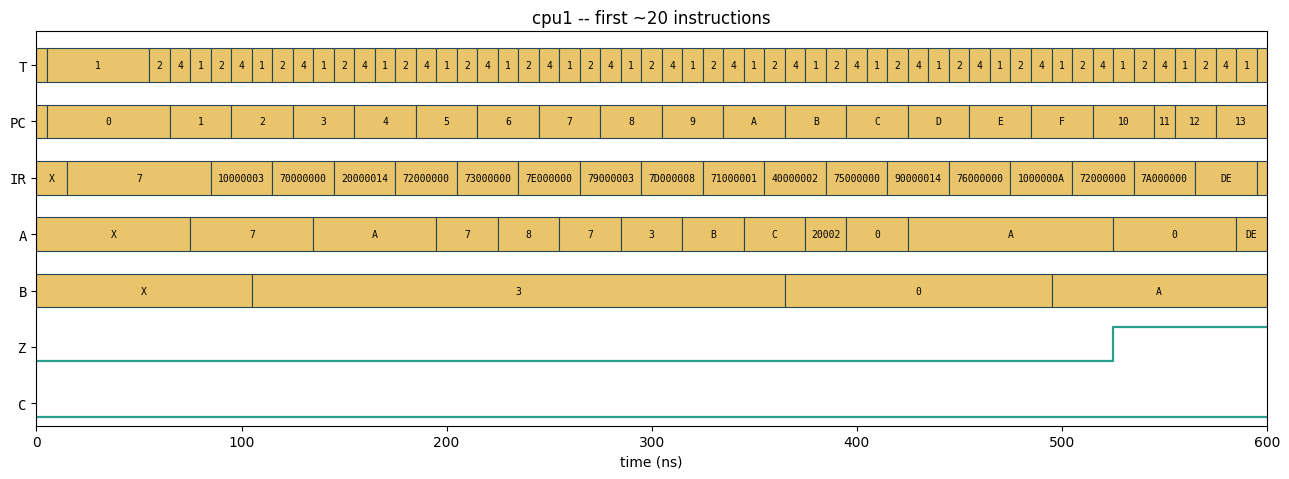

In [ ]:
vcd = VCDVCD("cpu1_waveform.vcd")
initial_vals = parse_initial_values("cpu1_waveform.vcd")
signals = [
    ("T", "tb_cpu1.outt[2:0]", "bus"),
    ("PC", "tb_cpu1.doutpc[31:0]", "bus"),
    ("IR", "tb_cpu1.doutir[31:0]", "bus"),
    ("A", "tb_cpu1.douta[31:0]", "bus"),
    ("B", "tb_cpu1.doutb[31:0]", "bus"),
    ("Z", "tb_cpu1.doutz", "bit"),
    ("C", "tb_cpu1.doutc", "bit"),
]
fig = plot_waveform(vcd, signals, 0, 600, "cpu1 -- first ~20 instructions", initial_vals=initial_vals)
plt.show()


### View 2 — the `clk` / `mem_clk` / `imem_clk` phase split (Finding #5)

This is the actual fix from Stage K, made visible: `mem_clk` (feeding `data_mem`) stays in phase with `clk`, while `imem_clk` (feeding the instruction memory) is deliberately inverted. Without this split, both memories shared one clock and a taken `TSTZ`/`TSTC` skip would read one cycle too early.

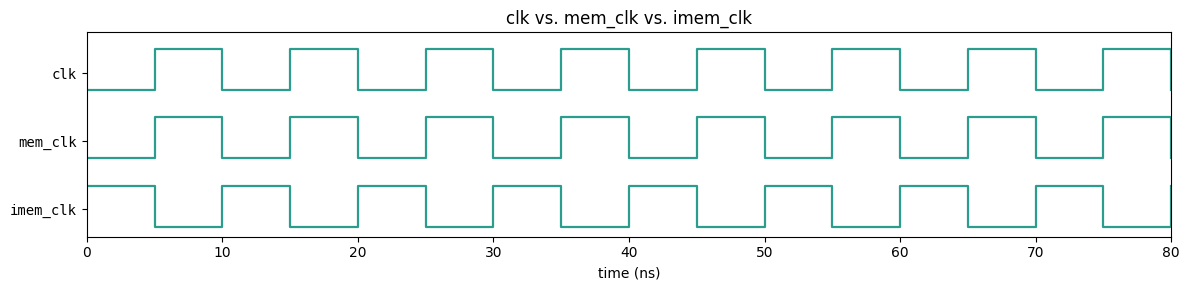

In [ ]:
vcd = VCDVCD("cpu1_waveform.vcd")
initial_vals = parse_initial_values("cpu1_waveform.vcd")
signals = [
    ("clk", "tb_cpu1.clk", "bit"),
    ("mem_clk", "tb_cpu1.mem_clk", "bit"),
    ("imem_clk", "tb_cpu1.imem_clk", "bit"),
]
fig = plot_waveform(vcd, signals, 0, 80, "clk vs. mem_clk vs. imem_clk", figsize=(12, 3), initial_vals=initial_vals)
plt.show()


### Reaching inside the hierarchy

Any internal signal works, not just the top-level debug ports. As an example, here's the actual `A` register's own load-enable pulsing alongside its output — visual, cycle-accurate confirmation that `ld_A` is what's actually driving each update.

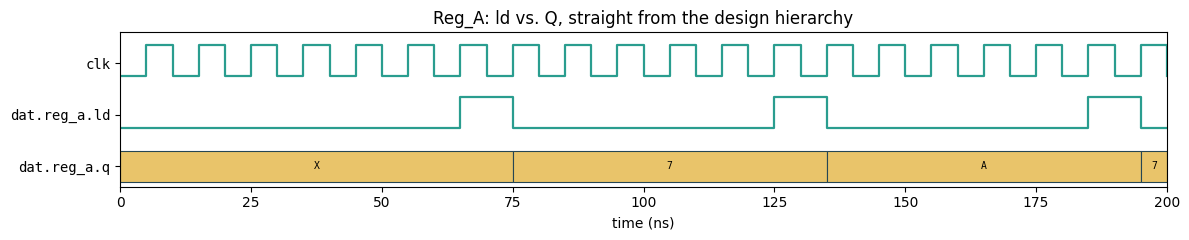

In [ ]:
vcd = VCDVCD("cpu1_waveform.vcd")
initial_vals = parse_initial_values("cpu1_waveform.vcd")
signals = [
    ("clk", "tb_cpu1.clk", "bit"),
    ("dat.reg_a.ld", "tb_cpu1.dut.dat.reg_a.ld", "bit"),
    ("dat.reg_a.q", "tb_cpu1.dut.dat.reg_a.q[31:0]", "bus"),
]
fig = plot_waveform(vcd, signals, 0, 200, "Reg_A: ld vs. Q, straight from the design hierarchy", figsize=(12, 2.5), initial_vals=initial_vals)
plt.show()


## Summary

Every stage — twelve independent testbenches plus the full integration — passes both its assertions **and** shows a matching waveform. Along the way, testing each module on its own (rather than only testing the assembled CPU) surfaced five genuine bugs and three documented quirks in the original repository that a whole-system test alone would have made much harder to isolate:

1. **ALU `Cout`/`zero` never driven** (Stage D) — fixed additively in `alu_fixed.vhd`.
2. **`data_path`'s Z/C status registers never implemented** (Stage J) — fixed additively in `data_path_fixed.vhd`.
3. **ALU port-map name/order mismatch swapping Z and C** (Stage J) — fixed via named port association.
4. **`LDB` wired to write instead of read** (Stage K) — fixed in `control_new_fixed.vhd`.
5. **Shared-clock phase conflict between the two memories** (Stage K) — fixed at the top-level testbench wiring.

Plus three real, faithfully-preserved characteristics: `BEQ`/`BNE` are unconditional jumps, `TSTZ`/`TSTC` can latch stale PC-control signals when their condition is false, and `LUI` can inherit a stale `IM_MUX2` selection from whatever instruction ran immediately before it.

None of these fixes change the instruction set, the opcode encoding, or any behavior the original design got right — each is the smallest possible change that makes something the code already clearly intended (a declared port, a named signal, a parallel instruction's pattern) actually work.

This machine is a genuinely different kind of design from a modern pipelined RISC-V core — two accumulators instead of a register file, a fixed 3-cycle-per-instruction FSM instead of overlapping pipeline stages, no hazards to speak of because nothing overlaps. If it's useful later, this same stage-by-stage, independently-verified methodology extends naturally to building a RISC-V core alongside it for comparison.
